# 04 Quant Integration Backtest — Prediction + Survival Risk + Volatility Targeting

This notebook adds a **quant decision layer** on top of your existing project:

1. Save row-level predictions from the statistical/deep-learning notebooks.
2. Save or construct a survival recovery-risk score.
3. Merge everything into one master signal table.
4. Build long/cash strategies.
5. Add survival-risk filtering.
6. Add volatility targeting.
7. Compare Sharpe, Sortino, maximum drawdown, VaR, Expected Shortfall, turnover, transaction-cost-adjusted return, and recovery time.

The key project idea is:

> Statistical/deep-learning models estimate expected return.  
> Survival analysis estimates recovery risk.  
> The quant layer decides how much ETF exposure to take.

In [36]:
# ============================================================
# 0. Imports and configuration
# ============================================================

import os
import gc
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    from IPython.display import display
except Exception:
    display = print

# Optional lifelines support for survival-risk scoring.
try:
    from lifelines import CoxPHFitter
    LIFELINES_AVAILABLE = True
except Exception:
    LIFELINES_AVAILABLE = False

# -----------------------------
# Kaggle-compatible paths
# -----------------------------
WORKING_DIR = "/kaggle/working" if os.path.exists("/kaggle/working") else "."

TARGET_TICKERS = ["SPY", "QQQ", "GLD", "VOO"]
HORIZONS = [1, 5, 10]

def find_first_csv(filename, search_roots=("/kaggle/input", "/mnt/data", ".")):
    """Find a CSV by filename. This avoids Kaggle folder-name mismatch issues."""
    for root0 in search_roots:
        if not os.path.exists(root0):
            continue
        for root, dirs, files in os.walk(root0):
            if filename in files:
                return os.path.join(root, filename)
    return None

def first_existing_path(candidates):
    for p in candidates:
        if p and os.path.exists(p):
            return p
    return None

# Raw adjusted-close price file.
DATA_PATH = first_existing_path([
    "/kaggle/input/datasets/ngc6523/raw-prices/adjusted_close_prices.csv",
    find_first_csv("adjusted_close_prices.csv"),
    "/mnt/data/adjusted_close_prices.csv",
])

# Required row-level prediction files from your older notebooks.
# These are NOT the model-summary CSVs; they must contain date-by-date predictions.
STAT_PRED_PATH = first_existing_path([
    "/kaggle/input/notebooks/ngc6523/etf-direction-classfication/statistical_model_predictions.csv",
    find_first_csv("statistical_model_predictions.csv"),
])

DL_PRED_PATH = first_existing_path([
    "/kaggle/input/notebooks/ngc6523/etf-prediction-with-feature-selection/deep_learning_model_predictions.csv",
    find_first_csv("deep_learning_model_predictions.csv"),
])

# Survival files.
# We deliberately do NOT use the old ETF-level survival_risk_scores.csv for the main strategy,
# because it creates flat horizontal risk lines. Section 3 rebuilds DAILY survival risk.
SURVIVAL_RISK_OLD_PATH = first_existing_path([
    "/kaggle/input/notebooks/ngc6523/survival-analysis-for-4-etfs/survival_risk_scores.csv",
    find_first_csv("survival_risk_scores.csv"),
])

RECOVERY_EPISODES_PATH = first_existing_path([
    "/kaggle/input/notebooks/ngc6523/survival-analysis-for-4-etfs/recovery_survival_dataset.csv",
    find_first_csv("recovery_survival_dataset.csv"),
])

VAR_EPISODES_PATH = first_existing_path([
    "/kaggle/input/notebooks/ngc6523/survival-analysis-for-4-etfs/var_breach_survival_dataset.csv",
    find_first_csv("var_breach_survival_dataset.csv"),
])

# Optional summary files, useful for reporting only.
DIRECTION_RESULTS_PATH = find_first_csv("etf_direction_model_results.csv")
AI_RESULTS_PATH = find_first_csv("etf_ai_model_results.csv")
SELECTED_FEATURES_PATH = find_first_csv("etf_selected_features.csv")

print("Checking input files:")
for name, path in [
    ("DATA_PATH", DATA_PATH),
    ("STAT_PRED_PATH", STAT_PRED_PATH),
    ("DL_PRED_PATH", DL_PRED_PATH),
    ("SURVIVAL_RISK_OLD_PATH", SURVIVAL_RISK_OLD_PATH),
    ("RECOVERY_EPISODES_PATH", RECOVERY_EPISODES_PATH),
    ("VAR_EPISODES_PATH", VAR_EPISODES_PATH),
]:
    print(f"{name:25s}", os.path.exists(path) if path else False, path)

if DATA_PATH is None or not os.path.exists(DATA_PATH):
    raise FileNotFoundError("Could not find adjusted_close_prices.csv. Add the raw-prices dataset to Kaggle.")

# Quant settings
TRANSACTION_COST_BPS = 5.0        # 5 bps per 100% turnover
TARGET_ANNUAL_VOL = 0.15          # less conservative than 10%; adjust if desired
MAX_POSITION = 1.0                # long/cash only; no leverage
MAX_VOL_SCALER = 1.25
MIN_VOL_SCALER = 0.25
RISK_FREE_RATE = 0.0
TRADING_DAYS = 252

# Signal settings
USE_PROBABILITY_SIGNAL = True
PROB_CENTER = 0.50
ENTRY_PERCENTILE = 0.55           # invest when signal is above its expanding 55th percentile
MIN_HISTORY_FOR_SIGNAL = 40       # expanding threshold starts after this many observations
SURVIVAL_PENALTY_STRENGTH = 0.40  # soft penalty; prevents Final Quant from staying all cash

# Prediction model selection policy.
# Current code uses mean ensemble across available models in each family.
MODEL_SELECTION_MODE = "mean"

print("\nWORKING_DIR:", WORKING_DIR)
print("lifelines available:", LIFELINES_AVAILABLE)


Checking input files:
DATA_PATH                 True /kaggle/input/datasets/ngc6523/raw-prices/adjusted_close_prices.csv
STAT_PRED_PATH            True /kaggle/input/notebooks/ngc6523/etf-direction-classfication/statistical_model_predictions.csv
DL_PRED_PATH              True /kaggle/input/notebooks/ngc6523/etf-prediction-with-feature-selection/deep_learning_model_predictions.csv
SURVIVAL_RISK_OLD_PATH    True /kaggle/input/notebooks/ngc6523/survival-analysis-for-4-etfs/survival_risk_scores.csv
RECOVERY_EPISODES_PATH    True /kaggle/input/notebooks/ngc6523/survival-analysis-for-4-etfs/recovery_survival_dataset.csv
VAR_EPISODES_PATH         True /kaggle/input/notebooks/ngc6523/survival-analysis-for-4-etfs/var_breach_survival_dataset.csv

WORKING_DIR: /kaggle/working
lifelines available: False


## 1. Export row-level predictions from your existing notebooks

Your current notebooks save summary results such as `etf_ai_model_results.csv`, but the quant backtest needs **date-level predictions**.

Run the next cell **at the end of your statistical/deep-learning notebook**, after `all_predictions` already exists.  
It creates two files:

- `statistical_model_predictions.csv`
- `deep_learning_model_predictions.csv`

If your old notebook already saves row-level predictions with these names, you can skip this section.

In [37]:
# ============================================================
# 1A. Export helper for old notebooks
# ============================================================
# Run this cell at the END of your existing prediction notebook, after all_predictions exists.
# It is safe to leave here too: if all_predictions is not defined, it will simply print a message.

STAT_MODEL_TYPES = {"classification", "return_regression", "statistical", "classical", "classical_ml"}
DL_MODEL_TYPES = {"deep_learning", "deep", "torch", "lstm", "gru", "mlp"}


def export_prediction_tables_from_all_predictions(
    all_predictions,
    results_df=None,
    stat_out_path="statistical_model_predictions.csv",
    dl_out_path="deep_learning_model_predictions.csv",
):
    """Export row-level predictions from your existing all_predictions dictionary.

    Expected all_predictions format from your notebooks:
        all_predictions[(target, horizon)][model_name] = {
            'prob_up': array,
            'pred_return': optional array,
            'y_dir': array,
            'y_ret': array,
            'dates': array,
            ...
        }
    """
    rows = []
    model_type_lookup = {}

    if results_df is not None and isinstance(results_df, pd.DataFrame):
        for _, r in results_df.iterrows():
            key = (str(r.get("target")), int(r.get("horizon")), str(r.get("model")))
            model_type_lookup[key] = str(r.get("model_type", "unknown"))

    for (target, horizon), model_dict in all_predictions.items():
        for model_name, info in model_dict.items():
            dates = pd.to_datetime(info.get("dates"))
            n = len(dates)
            prob_up = np.asarray(info.get("prob_up", [np.nan] * n), dtype=float)
            pred_return = np.asarray(info.get("pred_return", [np.nan] * n), dtype=float)
            y_ret = np.asarray(info.get("y_ret", [np.nan] * n), dtype=float)
            y_dir = np.asarray(info.get("y_dir", [np.nan] * n), dtype=float)

            model_type = model_type_lookup.get((str(target), int(horizon), str(model_name)), "unknown")
            if model_type == "unknown":
                name_lower = str(model_name).lower()
                if any(x in name_lower for x in ["lstm", "gru", "mlp", "rnn", "transformer"]):
                    model_type = "deep_learning"
                else:
                    model_type = "statistical"

            for i in range(n):
                rows.append({
                    "date": dates[i],
                    "ETF": target,
                    "horizon": int(horizon),
                    "model": model_name,
                    "model_type": model_type,
                    "prob_up": prob_up[i] if i < len(prob_up) else np.nan,
                    "pred_return": pred_return[i] if i < len(pred_return) else np.nan,
                    "actual_forward_return": y_ret[i] if i < len(y_ret) else np.nan,
                    "actual_direction": y_dir[i] if i < len(y_dir) else np.nan,
                })

    pred_df = pd.DataFrame(rows)
    if pred_df.empty:
        raise ValueError("No prediction rows were created. Check all_predictions structure.")

    pred_df["date"] = pd.to_datetime(pred_df["date"])

    stat_mask = ~pred_df["model_type"].str.lower().isin(DL_MODEL_TYPES)
    dl_mask = pred_df["model_type"].str.lower().isin(DL_MODEL_TYPES)

    stat_df = pred_df[stat_mask].copy()
    dl_df = pred_df[dl_mask].copy()

    if len(stat_df) > 0:
        stat_df.to_csv(stat_out_path, index=False)
        print(f"Saved statistical predictions: {stat_out_path} | shape={stat_df.shape}")
    else:
        print("No statistical/classical predictions detected.")

    if len(dl_df) > 0:
        dl_df.to_csv(dl_out_path, index=False)
        print(f"Saved deep-learning predictions: {dl_out_path} | shape={dl_df.shape}")
    else:
        print("No deep-learning predictions detected.")

    return stat_df, dl_df


# Auto-export only if this notebook is being run in the same session as the model notebook.
if "all_predictions" in globals():
    maybe_results_df = globals().get("results_df", None)
    export_prediction_tables_from_all_predictions(
        all_predictions=all_predictions,
        results_df=maybe_results_df,
        stat_out_path=STAT_PRED_PATH,
        dl_out_path=DL_PRED_PATH,
    )
else:
    print("all_predictions is not defined in this notebook session.")
    print("Run this export cell at the end of your existing model notebook, or upload prediction CSVs.")

all_predictions is not defined in this notebook session.
Run this export cell at the end of your existing model notebook, or upload prediction CSVs.


## 2. Load prices and build quant/risk features

These features are used for volatility targeting, benchmark returns, drawdown, and risk metrics.

In [38]:
# ============================================================
# 2. Load prices and create daily return / volatility / drawdown features
# ============================================================

prices_raw = pd.read_csv(DATA_PATH)

possible_date_cols = [c for c in prices_raw.columns if c.lower() in ["date", "datetime", "timestamp"]]
if len(possible_date_cols) == 0:
    raise ValueError("Could not find a date column. Please rename the date column to Date or edit this cell.")
DATE_COL = possible_date_cols[0]

prices_raw[DATE_COL] = pd.to_datetime(prices_raw[DATE_COL])
prices_raw = prices_raw.sort_values(DATE_COL).reset_index(drop=True)

available_tickers = [c for c in TARGET_TICKERS if c in prices_raw.columns]
if len(available_tickers) == 0:
    numeric_cols = prices_raw.select_dtypes(include=[np.number]).columns.tolist()
    available_tickers = numeric_cols[:4]
    print("TARGET_TICKERS not found. Using first numeric columns:", available_tickers)
else:
    print("Using target ETFs:", available_tickers)

prices = prices_raw[[DATE_COL] + available_tickers].copy()
for c in available_tickers:
    prices[c] = pd.to_numeric(prices[c], errors="coerce")

# Long format with one row per date and ETF.
long_rows = []
for etf in available_tickers:
    g = prices[[DATE_COL, etf]].rename(columns={DATE_COL: "date", etf: "AdjClose"}).copy()
    g["ETF"] = etf
    g = g.dropna(subset=["AdjClose"]).sort_values("date")
    g["daily_return"] = np.log(g["AdjClose"] / g["AdjClose"].shift(1))
    g["simple_daily_return"] = g["AdjClose"].pct_change()
    g["rolling_vol_20d"] = g["daily_return"].rolling(20).std()
    g["realized_vol_20d_ann"] = g["rolling_vol_20d"] * np.sqrt(TRADING_DAYS)
    g["momentum_20d"] = g["AdjClose"] / g["AdjClose"].shift(20) - 1
    g["rolling_mean_20d"] = g["daily_return"].rolling(20).mean()
    g["rolling_sharpe_20d"] = g["rolling_mean_20d"] / (g["rolling_vol_20d"] + 1e-12)
    g["running_max"] = g["AdjClose"].cummax()
    g["drawdown"] = g["AdjClose"] / g["running_max"] - 1.0
    g["loss"] = -g["daily_return"]
    g["hist_var_95_252d"] = g["loss"].rolling(252, min_periods=60).quantile(0.95)
    g["hist_es_95_252d"] = g["loss"].rolling(252, min_periods=60).apply(
        lambda x: np.mean(x[x >= np.quantile(x, 0.95)]) if len(x) > 0 else np.nan,
        raw=False,
    )
    long_rows.append(g)

market_df = pd.concat(long_rows, ignore_index=True)
market_df = market_df.sort_values(["ETF", "date"]).reset_index(drop=True)

print("market_df shape:", market_df.shape)
display(market_df.head())

Using target ETFs: ['SPY', 'QQQ', 'GLD', 'VOO']
market_df shape: (11064, 15)


,date,AdjClose,ETF,daily_return,simple_daily_return,rolling_vol_20d,realized_vol_20d_ann,momentum_20d,rolling_mean_20d,rolling_sharpe_20d,running_max,drawdown,loss,hist_var_95_252d,hist_es_95_252d
0,2015-01-02,114.080002,GLD,NaN,NaN,NaN,NaN,NaN,NaN,NaN,114.080002,0.000000,NaN,NaN,NaN
1,2015-01-05,115.800003,GLD,0.014965,0.015077,NaN,NaN,NaN,NaN,NaN,115.800003,0.000000,-0.014965,NaN,NaN
2,2015-01-06,117.120003,GLD,0.011334,0.011399,NaN,NaN,NaN,NaN,NaN,117.120003,0.000000,-0.011334,NaN,NaN
3,2015-01-07,116.430000,GLD,-0.005909,-0.005891,NaN,NaN,NaN,NaN,NaN,117.120003,-0.005891,0.005909,NaN,NaN
4,2015-01-08,115.940002,GLD,-0.004217,-0.004209,NaN,NaN,NaN,NaN,NaN,117.120003,-0.010075,0.004217,NaN,NaN


## 3. Create or load survival risk scores

Preferred input: `survival_risk_scores.csv` with columns:

```text
日期/date, ETF, survival_risk_score
```

If that file does not exist, this notebook tries to build a practical daily risk score from your survival notebook outputs:

- `recovery_survival_dataset.csv`
- `var_breach_survival_dataset.csv`

If those are also unavailable, it falls back to a transparent proxy based on drawdown depth, rolling volatility, and VaR breach pressure.

In [39]:
# ============================================================
# 3. Survival risk score construction
# ============================================================

def minmax_by_group(s):
    s = pd.Series(s).astype(float)
    lo, hi = s.min(), s.max()
    if not np.isfinite(lo) or not np.isfinite(hi) or abs(hi - lo) < 1e-12:
        return pd.Series(np.zeros(len(s)), index=s.index)
    return (s - lo) / (hi - lo)


def build_survival_risk_from_episode_files(market_df, recovery_path, var_path):
    """Build DAILY time-varying survival risk from market state + survival episode files.

    The score is explainable:
    - current drawdown risk: deeper current drawdown => higher risk;
    - volatility risk: higher rolling volatility percentile => higher risk;
    - historical VaR risk: higher rolling VaR percentile => higher risk;
    - recovery episode risk: longer/deeper recovery episodes from the survival notebook;
    - VaR breach episode risk: quick VaR breach episodes from the survival notebook.

    Output is date × ETF, so the risk score can move through time.
    """

    base = market_df[["date", "ETF", "drawdown", "rolling_vol_20d", "hist_var_95_252d"]].copy()
    base["date"] = pd.to_datetime(base["date"])
    base["ETF"] = base["ETF"].astype(str)

    base["drawdown_risk"] = base.groupby("ETF")["drawdown"].transform(
        lambda x: minmax_by_group((-x).clip(lower=0))
    )
    base["vol_risk"] = base.groupby("ETF")["rolling_vol_20d"].transform(
        lambda x: x.rank(pct=True).fillna(0)
    )
    base["var_risk"] = base.groupby("ETF")["hist_var_95_252d"].transform(
        lambda x: x.rank(pct=True).fillna(0)
    )

    pieces = [base]

    # Recovery episode risk by start date.
    if recovery_path is not None and os.path.exists(recovery_path):
        rec = pd.read_csv(recovery_path)
        rec.columns = [str(c).strip() for c in rec.columns]

        if "start_date" in rec.columns:
            rec["date"] = pd.to_datetime(rec["start_date"])
        elif "date" in rec.columns:
            rec["date"] = pd.to_datetime(rec["date"])
        else:
            rec = pd.DataFrame()

        if len(rec) > 0 and "ETF" in rec.columns and "duration" in rec.columns:
            rec["ETF"] = rec["ETF"].astype(str)
            keep = ["date", "ETF", "duration"]
            for c in ["event", "start_drawdown_depth", "roll_vol_21", "roll_mean_21"]:
                if c in rec.columns:
                    keep.append(c)

            rec_score = rec[keep].copy()
            rec_score["duration"] = pd.to_numeric(rec_score["duration"], errors="coerce")
            rec_score["recovery_duration_score"] = rec_score.groupby("ETF")["duration"].transform(minmax_by_group)

            if "start_drawdown_depth" in rec_score.columns:
                rec_score["start_drawdown_depth"] = pd.to_numeric(rec_score["start_drawdown_depth"], errors="coerce").fillna(0)
                rec_score["recovery_depth_score"] = rec_score.groupby("ETF")["start_drawdown_depth"].transform(minmax_by_group)
            else:
                rec_score["recovery_depth_score"] = 0.0

            rec_score["recovery_episode_risk"] = (
                0.60 * rec_score["recovery_duration_score"].fillna(0)
                + 0.40 * rec_score["recovery_depth_score"].fillna(0)
            ).clip(0, 1)

            rec_score = rec_score.groupby(["date", "ETF"], as_index=False)["recovery_episode_risk"].mean()
            pieces.append(rec_score)
            print("Loaded recovery episodes:", rec.shape)
        else:
            print("Recovery episode file found, but required columns are missing.")
    else:
        print("No recovery episode file found:", recovery_path)

    # VaR breach risk by start date.
    if var_path is not None and os.path.exists(var_path):
        var = pd.read_csv(var_path)
        var.columns = [str(c).strip() for c in var.columns]

        if "start_date" in var.columns:
            var["date"] = pd.to_datetime(var["start_date"])
        elif "date" in var.columns:
            var["date"] = pd.to_datetime(var["date"])
        else:
            var = pd.DataFrame()

        if len(var) > 0 and "ETF" in var.columns and "event" in var.columns and "duration" in var.columns:
            var["ETF"] = var["ETF"].astype(str)
            keep = ["date", "ETF", "event", "duration"]
            for c in ["VaR_95_start", "roll_vol_21", "start_loss"]:
                if c in var.columns:
                    keep.append(c)

            var_score = var[keep].copy()
            var_score["event"] = pd.to_numeric(var_score["event"], errors="coerce").fillna(0)
            var_score["duration"] = pd.to_numeric(var_score["duration"], errors="coerce")

            max_dur = var_score.groupby("ETF")["duration"].transform("max").replace(0, np.nan)
            var_score["quick_breach_score"] = var_score["event"] * (
                1 - (var_score["duration"] / max_dur).clip(0, 1)
            )

            if "VaR_95_start" in var_score.columns:
                var_score["VaR_95_start"] = pd.to_numeric(var_score["VaR_95_start"], errors="coerce")
                var_score["var_level_score"] = var_score.groupby("ETF")["VaR_95_start"].transform(
                    lambda x: x.rank(pct=True).fillna(0)
                )
            else:
                var_score["var_level_score"] = 0.0

            var_score["var_episode_risk"] = (
                0.70 * var_score["quick_breach_score"].fillna(0)
                + 0.30 * var_score["var_level_score"].fillna(0)
            ).clip(0, 1)

            var_score = var_score.groupby(["date", "ETF"], as_index=False)["var_episode_risk"].mean()
            pieces.append(var_score)
            print("Loaded VaR breach episodes:", var.shape)
        else:
            print("VaR episode file found, but required columns are missing.")
    else:
        print("No VaR episode file found:", var_path)

    out = pieces[0]
    for p in pieces[1:]:
        out = out.merge(p, on=["date", "ETF"], how="left")

    # Event risks occur only on event start dates; forward-fill to represent current risk state.
    for c in ["recovery_episode_risk", "var_episode_risk"]:
        if c not in out.columns:
            out[c] = np.nan
        out[c] = out.groupby("ETF")[c].ffill().fillna(0.0).clip(0, 1)

    out["market_state_risk"] = (
        0.45 * out["drawdown_risk"].fillna(0)
        + 0.35 * out["vol_risk"].fillna(0)
        + 0.20 * out["var_risk"].fillna(0)
    ).clip(0, 1)

    out["survival_risk_score"] = (
        0.45 * out["market_state_risk"].fillna(0)
        + 0.35 * out["recovery_episode_risk"].fillna(0)
        + 0.20 * out["var_episode_risk"].fillna(0)
    ).clip(0, 1)

    keep_cols = [
        "date", "ETF", "survival_risk_score", "market_state_risk",
        "recovery_episode_risk", "var_episode_risk",
        "drawdown_risk", "vol_risk", "var_risk"
    ]
    return out[keep_cols].copy()


# IMPORTANT:
# Force DAILY risk construction. Do not load the old ETF-level survival_risk_scores.csv,
# because that creates flat horizontal lines and makes the survival filter uninformative.
survival_risk = build_survival_risk_from_episode_files(
    market_df=market_df,
    recovery_path=RECOVERY_EPISODES_PATH,
    var_path=VAR_EPISODES_PATH,
)

SURVIVAL_RISK_DAILY_OUTPUT = os.path.join(WORKING_DIR, "survival_risk_scores_daily.csv")
survival_risk.to_csv(SURVIVAL_RISK_DAILY_OUTPUT, index=False)

print("\nCreated time-varying daily survival risk scores:")
print(SURVIVAL_RISK_DAILY_OUTPUT)
print("Shape:", survival_risk.shape)
print("Columns:", survival_risk.columns.tolist())

display(survival_risk.head())


Loaded recovery episodes: (634, 9)
Loaded VaR breach episodes: (10808, 11)

Created time-varying daily survival risk scores:
/kaggle/working/survival_risk_scores_daily.csv
Shape: (11064, 9)
Columns: ['date', 'ETF', 'survival_risk_score', 'market_state_risk', 'recovery_episode_risk', 'var_episode_risk', 'drawdown_risk', 'vol_risk', 'var_risk']


,date,ETF,survival_risk_score,market_state_risk,recovery_episode_risk,var_episode_risk,drawdown_risk,vol_risk,var_risk
0,2015-01-02,GLD,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.0
1,2015-01-05,GLD,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.0
2,2015-01-06,GLD,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.0
3,2015-01-07,GLD,0.018324,0.012049,0.036863,0.0,0.026777,0.0,0.0
4,2015-01-08,GLD,0.022175,0.020606,0.036863,0.0,0.045792,0.0,0.0


In [40]:
# Check whether survival risk is time-varying
risk_check = survival_risk.groupby("ETF")["survival_risk_score"].agg(
    ["min", "mean", "max", "std"]
).reset_index()

display(risk_check)

if (risk_check["std"].fillna(0) < 1e-8).any():
    print("Warning: at least one ETF still has almost-flat survival risk. Check recovery/VaR episode files.")
else:
    print("Good: survival risk is time-varying for all ETFs.")


,ETF,min,mean,max,std
0,GLD,0.0,0.466828,0.793786,0.146543
1,QQQ,0.0,0.344382,0.822372,0.178333
2,SPY,0.0,0.334664,0.761333,0.161943
3,VOO,0.0,0.332265,0.760761,0.161120


Good: survival risk is time-varying for all ETFs.


## 4. Load statistical and deep-learning prediction files

Expected prediction file columns:

```text
date, ETF, horizon, model, model_type, prob_up, pred_return, actual_forward_return, actual_direction
```

The export helper above creates exactly this format from your existing `all_predictions` dictionary.

In [41]:
# ============================================================
# 4. Load prediction files
# ============================================================

def remove_duplicate_columns(df):
    """Remove duplicate column names, which can cause groupby errors."""
    df = df.copy()
    df.columns = [str(c).strip() for c in df.columns]
    df = df.loc[:, ~df.columns.duplicated()].copy()
    return df


def load_prediction_file(path, family_name):
    if path is None or not os.path.exists(path):
        print(f"Missing {family_name} prediction file: {path}")
        return pd.DataFrame()

    df = pd.read_csv(path)
    df.columns = [str(c).strip() for c in df.columns]

    print(f"\nOriginal columns for {family_name}:")
    print(df.columns.tolist())

    df = remove_duplicate_columns(df)

    rename_map = {}
    for c in df.columns:
        lc = c.lower().strip()

        if lc in ["dates", "datetime", "timestamp", "time"]:
            rename_map[c] = "date"

        # Only rename target/ticker/symbol to ETF if ETF does not already exist.
        # This avoids duplicate ETF columns.
        elif lc in ["target", "ticker", "symbol"] and "ETF" not in df.columns:
            rename_map[c] = "ETF"

        elif lc in ["y_ret", "actual_return", "future_return", "forward_return"]:
            rename_map[c] = "actual_forward_return"

        elif lc in ["y_dir", "actual_label", "direction", "actual_up", "label"]:
            rename_map[c] = "actual_direction"

        elif lc in ["pred_prob_up", "probability_up", "predicted_prob_up", "y_prob", "prob"]:
            rename_map[c] = "prob_up"

        elif lc in ["predicted_return", "y_pred_return", "pred_ret", "prediction"]:
            rename_map[c] = "pred_return"

    if rename_map:
        df = df.rename(columns=rename_map)

    df = remove_duplicate_columns(df)

    required = ["date", "ETF", "horizon", "model"]
    missing = [c for c in required if c not in df.columns]
    if missing:
        raise ValueError(
            f"{family_name} prediction file is missing required columns: {missing}. "
            f"Columns are: {df.columns.tolist()}"
        )

    if "target" not in df.columns:
        df["target"] = df["ETF"]

    df["date"] = pd.to_datetime(df["date"])
    df["ETF"] = df["ETF"].astype(str)
    df["target"] = df["target"].astype(str)
    df["horizon"] = df["horizon"].astype(int)
    df["prediction_family"] = family_name

    for c in ["prob_up", "pred_return", "actual_forward_return", "actual_direction"]:
        if c not in df.columns:
            df[c] = np.nan
        df[c] = pd.to_numeric(df[c], errors="coerce")

    print(f"\nStandardized columns for {family_name}:")
    print(df.columns.tolist())
    print("Shape:", df.shape)
    print("Duplicated columns:", df.columns[df.columns.duplicated()].tolist())

    return df


stat_pred = load_prediction_file(STAT_PRED_PATH, "statistical")
dl_pred = load_prediction_file(DL_PRED_PATH, "deep_learning")

print("\nstat_pred shape:", stat_pred.shape)
print("dl_pred shape:", dl_pred.shape)

if len(stat_pred) == 0 and len(dl_pred) == 0:
    raise FileNotFoundError(
        "No row-level prediction CSVs were found. Run the export helper at the end of your old prediction notebooks first. "
        f"Expected files: {STAT_PRED_PATH} and/or {DL_PRED_PATH}"
    )

display(pd.concat([stat_pred.head(), dl_pred.head()], ignore_index=True))



Original columns for statistical:
['date', 'ETF', 'target', 'horizon', 'model', 'model_type', 'prob_up', 'pred_return', 'actual_direction', 'actual_forward_return', 'threshold', 'long_threshold', 'short_threshold']

Standardized columns for statistical:
['date', 'ETF', 'target', 'horizon', 'model', 'model_type', 'prob_up', 'pred_return', 'actual_direction', 'actual_forward_return', 'threshold', 'long_threshold', 'short_threshold', 'prediction_family']
Shape: (69628, 14)
Duplicated columns: []

Original columns for deep_learning:
['date', 'ETF', 'target', 'horizon', 'model', 'model_type', 'prob_up', 'pred_return', 'actual_direction', 'actual_forward_return', 'threshold', 'long_threshold', 'short_threshold']

Standardized columns for deep_learning:
['date', 'ETF', 'target', 'horizon', 'model', 'model_type', 'prob_up', 'pred_return', 'actual_direction', 'actual_forward_return', 'threshold', 'long_threshold', 'short_threshold', 'prediction_family']
Shape: (63140, 14)
Duplicated columns: [

,date,ETF,target,horizon,model,model_type,prob_up,pred_return,actual_direction,actual_forward_return,threshold,long_threshold,short_threshold,prediction_family
0,2023-12-14,GLD,GLD,1,CNNLSTMClassifier,statistical,0.735482,NaN,0.0,-0.009209,0.5,NaN,NaN,statistical
1,2023-12-15,GLD,GLD,1,CNNLSTMClassifier,statistical,0.870566,NaN,1.0,0.004535,0.5,NaN,NaN,statistical
2,2023-12-18,GLD,GLD,1,CNNLSTMClassifier,statistical,0.760922,NaN,1.0,0.006791,0.5,NaN,NaN,statistical
3,2023-12-19,GLD,GLD,1,CNNLSTMClassifier,statistical,0.301267,NaN,0.0,-0.005461,0.5,NaN,NaN,statistical
4,2023-12-20,GLD,GLD,1,CNNLSTMClassifier,statistical,0.820513,NaN,1.0,0.007046,0.5,NaN,NaN,statistical
5,2023-12-14,GLD,GLD,1,Attention_GRU,deep_learning,0.503998,NaN,0.0,-0.009209,0.5,NaN,NaN,deep_learning
6,2023-12-15,GLD,GLD,1,Attention_GRU,deep_learning,0.509995,NaN,1.0,0.004535,0.5,NaN,NaN,deep_learning
7,2023-12-18,GLD,GLD,1,Attention_GRU,deep_learning,0.510075,NaN,1.0,0.006791,0.5,NaN,NaN,deep_learning
8,2023-12-19,GLD,GLD,1,Attention_GRU,deep_learning,0.506105,NaN,0.0,-0.005461,0.5,NaN,NaN,deep_learning
9,2023-12-20,GLD,GLD,1,Attention_GRU,deep_learning,0.495055,NaN,1.0,0.007046,0.5,NaN,NaN,deep_learning


## 5. Convert model predictions into family-level signals

For each `date × ETF × horizon`, we create:

- a statistical model signal;
- a deep-learning model signal;
- a combined prediction signal.

If probability predictions exist, the score is centered at 0.5:

```text
score = prob_up - 0.5
```

If only return predictions exist, the score uses predicted return directly.

In [42]:
# ============================================================
# 5. Aggregate prediction signals by family
# ============================================================

def add_model_signal(df):
    df = df.copy()
    if USE_PROBABILITY_SIGNAL and "prob_up" in df.columns:
        df["model_signal"] = df["prob_up"] - PROB_CENTER
        # If prob_up is missing for some regression models, fallback to predicted return.
        missing = df["model_signal"].isna()
        df.loc[missing, "model_signal"] = df.loc[missing, "pred_return"]
    else:
        df["model_signal"] = df["pred_return"]
    return df


def aggregate_family_predictions(df, family_name):
    if len(df) == 0:
        return pd.DataFrame()
    df = add_model_signal(df)

    group_cols = ["date", "ETF", "horizon"]

    if MODEL_SELECTION_MODE == "mean":
        agg = df.groupby(group_cols, as_index=False).agg(
            family_signal=("model_signal", "mean"),
            family_prob_up=("prob_up", "mean"),
            family_pred_return=("pred_return", "mean"),
            actual_forward_return=("actual_forward_return", "first"),
            actual_direction=("actual_direction", "first"),
            n_models=("model", "nunique"),
        )
        agg["selected_model"] = "mean_ensemble"
    else:
        # Conservative fallback: choose model with highest average signal/return correlation proxy.
        # For simplicity and robustness, this still uses average if no validation metric is supplied.
        agg = df.groupby(group_cols, as_index=False).agg(
            family_signal=("model_signal", "mean"),
            family_prob_up=("prob_up", "mean"),
            family_pred_return=("pred_return", "mean"),
            actual_forward_return=("actual_forward_return", "first"),
            actual_direction=("actual_direction", "first"),
            n_models=("model", "nunique"),
        )
        agg["selected_model"] = "mean_ensemble_fallback"

    agg = agg.rename(columns={
        "family_signal": f"{family_name}_signal",
        "family_prob_up": f"{family_name}_prob_up",
        "family_pred_return": f"{family_name}_pred_return",
        "n_models": f"{family_name}_n_models",
        "selected_model": f"{family_name}_selected_model",
    })
    return agg

stat_signal = aggregate_family_predictions(stat_pred, "stat")
dl_signal = aggregate_family_predictions(dl_pred, "dl")

print("stat_signal shape:", stat_signal.shape)
print("dl_signal shape:", dl_signal.shape)
display(stat_signal.head())
display(dl_signal.head())

stat_signal shape: (6488, 10)
dl_signal shape: (6488, 10)


,date,ETF,horizon,stat_signal,stat_prob_up,stat_pred_return,actual_forward_return,actual_direction,stat_n_models,stat_selected_model
0,2023-10-23,GLD,10,0.063675,0.563675,0.001341,0.002075,1.0,6,mean_ensemble
1,2023-10-23,QQQ,10,0.042183,0.542183,0.005970,0.037362,1.0,6,mean_ensemble
2,2023-10-23,SPY,10,0.043455,0.543455,0.004172,0.035582,1.0,6,mean_ensemble
3,2023-10-23,VOO,10,0.043067,0.543067,0.003271,0.035349,1.0,6,mean_ensemble
4,2023-10-24,GLD,10,0.014587,0.514587,0.000709,-0.001970,0.0,6,mean_ensemble


,date,ETF,horizon,dl_signal,dl_prob_up,dl_pred_return,actual_forward_return,actual_direction,dl_n_models,dl_selected_model
0,2023-10-23,GLD,10,0.272532,0.772532,0.007802,0.002075,1.0,5,mean_ensemble
1,2023-10-23,QQQ,10,0.140228,0.640228,0.002336,0.037362,1.0,5,mean_ensemble
2,2023-10-23,SPY,10,-0.015072,0.484928,0.002575,0.035582,1.0,5,mean_ensemble
3,2023-10-23,VOO,10,-0.011855,0.488145,0.003762,0.035349,1.0,5,mean_ensemble
4,2023-10-24,GLD,10,0.251076,0.751076,0.006808,-0.001970,0.0,5,mean_ensemble


## 6. Merge predictions + survival risk + market features into one signal table

In [43]:
# ============================================================
# 6. Build master signal table
# ============================================================

# Start from whichever signal table exists.
if len(stat_signal) > 0:
    master = stat_signal.copy()
    if len(dl_signal) > 0:
        dl_cols = [c for c in dl_signal.columns if c not in ["actual_forward_return", "actual_direction"]]
        master = master.merge(dl_signal[dl_cols], on=["date", "ETF", "horizon"], how="outer")
elif len(dl_signal) > 0:
    master = dl_signal.copy()
else:
    raise ValueError("No signal data available.")

# Fill actual forward return/direction from either family if needed.
actual_source = pd.concat([stat_pred, dl_pred], ignore_index=True)
if len(actual_source) > 0:
    actual_source = actual_source.groupby(["date", "ETF", "horizon"], as_index=False).agg(
        actual_forward_return=("actual_forward_return", "first"),
        actual_direction=("actual_direction", "first"),
    )
    master = master.drop(columns=[c for c in ["actual_forward_return", "actual_direction"] if c in master.columns])
    master = master.merge(actual_source, on=["date", "ETF", "horizon"], how="left")

# Add daily market data and daily survival risk.
market_cols = [
    "date", "ETF", "AdjClose", "daily_return", "simple_daily_return", "rolling_vol_20d",
    "realized_vol_20d_ann", "momentum_20d", "rolling_sharpe_20d", "drawdown",
    "hist_var_95_252d", "hist_es_95_252d"
]
master = master.merge(market_df[market_cols], on=["date", "ETF"], how="left")
master = master.merge(survival_risk, on=["date", "ETF"], how="left")

# Fill survival risk if dates do not match perfectly.
master = master.sort_values(["ETF", "horizon", "date"]).reset_index(drop=True)
master["survival_risk_score"] = (
    master.groupby(["ETF", "horizon"])["survival_risk_score"]
    .ffill()
    .bfill()
    .fillna(0.0)
    .clip(0, 1)
)

# Combined prediction signal: use both if available, otherwise use the available family.
signal_cols = [c for c in ["stat_signal", "dl_signal"] if c in master.columns]
master["combined_signal"] = master[signal_cols].mean(axis=1).fillna(0.0)

# Soft survival-adjusted signal. This is NOT a hard cutoff.
master["survival_multiplier"] = (
    1.0 - SURVIVAL_PENALTY_STRENGTH * master["survival_risk_score"]
).clip(0.50, 1.00)
master["survival_adjusted_signal"] = master["combined_signal"] * master["survival_multiplier"]

master_path = os.path.join(WORKING_DIR, "quant_master_signal_table.csv")
master.to_csv(master_path, index=False)

print("master shape:", master.shape)
print("Saved:", master_path)
display(master.head())


master shape: (6488, 35)
Saved: /kaggle/working/quant_master_signal_table.csv


,date,ETF,horizon,stat_signal,stat_prob_up,stat_pred_return,stat_n_models,stat_selected_model,dl_signal,dl_prob_up,...,survival_risk_score,market_state_risk,recovery_episode_risk,var_episode_risk,drawdown_risk,vol_risk,var_risk,combined_signal,survival_multiplier,survival_adjusted_signal
0,2023-11-02,GLD,1,0.166878,0.666878,0.006125,6,mean_ensemble,0.222235,0.722235,...,0.560458,0.403691,0.698475,0.671655,0.229020,0.681355,0.310791,0.194557,0.775817,0.150940
1,2023-11-03,GLD,1,-0.008508,0.491492,0.000115,6,mean_ensemble,0.224812,0.724812,...,0.559385,0.396369,0.698475,0.682766,0.213315,0.680626,0.310791,0.108152,0.776246,0.083952
2,2023-11-06,GLD,1,-0.025796,0.474204,-0.000952,6,mean_ensemble,0.205546,0.705546,...,0.563109,0.399705,0.698475,0.693877,0.247070,0.646759,0.310791,0.089875,0.774756,0.069631
3,2023-11-07,GLD,1,-0.033411,0.466589,-0.000379,6,mean_ensemble,0.184887,0.684887,...,0.571004,0.412311,0.698475,0.704988,0.264885,0.659869,0.310791,0.075738,0.771599,0.058439
4,2023-11-08,GLD,1,-0.072528,0.427472,-0.001247,6,mean_ensemble,-0.037516,0.462484,...,0.592153,0.448333,0.698475,0.729684,0.307548,0.707939,0.310791,-0.055022,0.763139,-0.041990


## 7. Build strategies

We compare five strategies:

1. **Buy & Hold**: always hold the ETF.
2. **Statistical Only**: position from statistical model signal.
3. **Deep Learning Only**: position from deep-learning signal.
4. **Stat + DL Ensemble**: position from combined prediction signal.
5. **Stat + DL + Survival Risk + Vol Target**: final quant strategy.

All strategy returns use `position.shift(1)` to avoid look-ahead bias.

In [44]:
# ============================================================
# 7. Strategy construction
# Continuous quant allocation + soft survival risk + vol targeting
# ============================================================

# ------------------------------------------------------------
# Strategy parameters
# ------------------------------------------------------------

SIGNAL_EWM_SPAN = 10              # smooth prediction signal
MIN_HISTORY_FOR_SIGNAL = 60       # expanding history before signal becomes reliable

SURVIVAL_PENALTY_STRENGTH = 0.25  # softer survival penalty
SURVIVAL_MULTIPLIER_FLOOR = 0.70  # never reduce exposure too aggressively

TARGET_ANNUAL_VOL = 0.18          # closer to ETF risk; 0.10 was too conservative
MIN_VOL_SCALER = 0.50
MAX_VOL_SCALER = 1.00             # no leverage

BASE_EXPOSURE = 0.25              # final quant always keeps at least 25% exposure
MAX_POSITION = 1.00

MAX_POSITION_CHANGE_PER_DAY = 0.10  # smooth daily allocation changes
TRANSACTION_COST = TRANSACTION_COST_BPS / 10000.0


# ------------------------------------------------------------
# Helper 1: continuous position from model signal
# ------------------------------------------------------------

def continuous_position_from_signal(
    signal,
    ewm_span=SIGNAL_EWM_SPAN,
    min_history=MIN_HISTORY_FOR_SIGNAL,
):
    """
    Convert noisy model signal into continuous exposure between 0 and 1.

    This avoids the previous barcode-looking 0/1 position plot.

    Logic:
    - Smooth signal using EWMA.
    - Standardize using expanding mean/std shifted by one day.
    - Convert z-score into a continuous allocation using a sigmoid curve.
    """

    s = pd.Series(signal).astype(float).replace([np.inf, -np.inf], np.nan).fillna(0.0)

    smooth = s.ewm(span=ewm_span, adjust=False).mean()

    expanding_mean = smooth.expanding(min_periods=min_history).mean().shift(1)
    expanding_std = smooth.expanding(min_periods=min_history).std().shift(1)

    z = (smooth - expanding_mean) / expanding_std
    z = z.replace([np.inf, -np.inf], np.nan).fillna(0.0)
    z = z.clip(-3, 3)

    # Sigmoid transforms signal into [0,1]
    raw_position = 1 / (1 + np.exp(-z))

    # Make weak signals closer to cash, strong signals closer to fully invested
    position = (raw_position - 0.35) / 0.45
    position = position.clip(0, 1)

    return pd.Series(position, index=s.index)


# ------------------------------------------------------------
# Helper 2: limit daily position jumps
# ------------------------------------------------------------

def limit_position_turnover(pos, max_change=MAX_POSITION_CHANGE_PER_DAY):
    """
    Prevent position from jumping too much from one day to the next.
    This makes the strategy more realistic and reduces over-trading.
    """

    pos = pd.Series(pos).astype(float).replace([np.inf, -np.inf], np.nan).fillna(0.0)

    if len(pos) == 0:
        return pos

    out = pos.copy()
    out.iloc[0] = pos.iloc[0]

    for i in range(1, len(pos)):
        previous = out.iloc[i - 1]
        desired = pos.iloc[i]
        change = desired - previous
        change = np.clip(change, -max_change, max_change)
        out.iloc[i] = previous + change

    return out.clip(0, 1)


# ------------------------------------------------------------
# Main strategy function
# ------------------------------------------------------------

def add_strategy_returns(g):
    g = g.sort_values("date").copy()

    # --------------------------------------------------------
    # 1. Buy-and-hold baseline
    # --------------------------------------------------------
    g["pos_buy_hold"] = 1.0

    # --------------------------------------------------------
    # 2. Prediction-only continuous positions
    # --------------------------------------------------------
    if "stat_signal" in g.columns:
        g["pos_stat_only"] = continuous_position_from_signal(g["stat_signal"])
    else:
        g["pos_stat_only"] = 0.0

    if "dl_signal" in g.columns:
        g["pos_dl_only"] = continuous_position_from_signal(g["dl_signal"])
    else:
        g["pos_dl_only"] = 0.0

    g["pos_ensemble"] = continuous_position_from_signal(g["combined_signal"])

    # --------------------------------------------------------
    # 3. Soft survival-risk multiplier
    # Higher recovery risk reduces exposure, but does not kill it.
    # --------------------------------------------------------
    g["survival_risk_score"] = g["survival_risk_score"].clip(0, 1)

    g["survival_multiplier"] = (
        1.0 - SURVIVAL_PENALTY_STRENGTH * g["survival_risk_score"]
    ).clip(SURVIVAL_MULTIPLIER_FLOOR, 1.00)

    g["pos_ensemble_survival_filter"] = (
        g["pos_ensemble"] * g["survival_multiplier"]
    ).clip(0, MAX_POSITION)

    # --------------------------------------------------------
    # 4. Volatility targeting
    # This scales exposure down during high-volatility periods.
    # --------------------------------------------------------
    realized_vol = g["realized_vol_20d_ann"].replace(0, np.nan)

    vol_scaler = TARGET_ANNUAL_VOL / realized_vol
    vol_scaler = vol_scaler.replace([np.inf, -np.inf], np.nan)
    vol_scaler = vol_scaler.ffill().bfill().fillna(1.0)
    vol_scaler = vol_scaler.clip(MIN_VOL_SCALER, MAX_VOL_SCALER)

    g["vol_scaler"] = vol_scaler

    # --------------------------------------------------------
    # 5. Final quant position
    # Add base exposure so the strategy does not miss the entire bull market.
    # --------------------------------------------------------
    raw_dynamic_position = (
        g["pos_ensemble_survival_filter"] * g["vol_scaler"]
    ).clip(0, MAX_POSITION)

    g["raw_pos_quant_final"] = (
        BASE_EXPOSURE + (1 - BASE_EXPOSURE) * raw_dynamic_position
    ).clip(0, MAX_POSITION)

    # Smooth final position by limiting day-to-day changes
    g["pos_quant_final"] = limit_position_turnover(
        g["raw_pos_quant_final"],
        max_change=MAX_POSITION_CHANGE_PER_DAY,
    )

    position_cols = [
        "pos_buy_hold",
        "pos_stat_only",
        "pos_dl_only",
        "pos_ensemble",
        "pos_ensemble_survival_filter",
        "pos_quant_final",
    ]

    # --------------------------------------------------------
    # 6. Strategy returns
    # Use shifted position to avoid look-ahead bias.
    # --------------------------------------------------------
    for pos_col in position_cols:
        ret_col = pos_col.replace("pos_", "ret_")
        net_col = ret_col + "_net"
        turnover_col = pos_col.replace("pos_", "turnover_")

        position = g[pos_col].astype(float).fillna(0.0)

        gross_return = position.shift(1).fillna(0.0) * g["daily_return"].fillna(0.0)
        turnover = position.diff().abs().fillna(position.abs())
        cost = TRANSACTION_COST * turnover
        net_return = gross_return - cost

        g[ret_col] = gross_return
        g[net_col] = net_return
        g[turnover_col] = turnover

    return g


# ------------------------------------------------------------
# Apply strategy by ETF and horizon
# ------------------------------------------------------------

strategy_df = master.groupby(["ETF", "horizon"], group_keys=False).apply(add_strategy_returns)
strategy_df = strategy_df.reset_index(drop=True)

strategy_path = os.path.join(WORKING_DIR, "quant_strategy_returns.csv")
strategy_df.to_csv(strategy_path, index=False)

print("strategy_df shape:", strategy_df.shape)
print("Saved:", strategy_path)

position_cols = [c for c in strategy_df.columns if c.startswith("pos_")]
print("Position columns:", position_cols)

display(strategy_df.head())

# ------------------------------------------------------------
# Exposure diagnostics
# ------------------------------------------------------------

exposure_summary = strategy_df.groupby(["ETF", "horizon"])[position_cols].agg(
    ["min", "mean", "max", "std"]
)

exposure_path = os.path.join(WORKING_DIR, "quant_position_exposure_diagnostics.csv")
exposure_summary.to_csv(exposure_path)

print("Saved exposure diagnostics:", exposure_path)
display(exposure_summary)

strategy_df shape: (6488, 61)
Saved: /kaggle/working/quant_strategy_returns.csv
Position columns: ['pos_buy_hold', 'pos_stat_only', 'pos_dl_only', 'pos_ensemble', 'pos_ensemble_survival_filter', 'pos_quant_final']


,date,ETF,horizon,stat_signal,stat_prob_up,stat_pred_return,stat_n_models,stat_selected_model,dl_signal,dl_prob_up,...,turnover_dl_only,ret_ensemble,ret_ensemble_net,turnover_ensemble,ret_ensemble_survival_filter,ret_ensemble_survival_filter_net,turnover_ensemble_survival_filter,ret_quant_final,ret_quant_final_net,turnover_quant_final
0,2023-11-02,GLD,1,0.166878,0.666878,0.006125,6,mean_ensemble,0.222235,0.722235,...,0.333333,0.000000,-0.000167,0.333333,0.000000,-0.000143,0.286628,0.000000,-0.000232,0.464971
1,2023-11-03,GLD,1,-0.008508,0.491492,0.000115,6,mean_ensemble,0.224812,0.724812,...,0.000000,0.001211,0.001211,0.000000,0.001041,0.001041,0.000089,0.001689,0.001689,0.000067
2,2023-11-06,GLD,1,-0.025796,0.474204,-0.000952,6,mean_ensemble,0.205546,0.705546,...,0.000000,-0.002608,-0.002608,0.000000,-0.002243,-0.002243,0.000310,-0.003638,-0.003638,0.000233
3,2023-11-07,GLD,1,-0.033411,0.466589,-0.000379,6,mean_ensemble,0.184887,0.684887,...,0.000000,-0.001385,-0.001385,0.000000,-0.001190,-0.001190,0.000658,-0.001931,-0.001931,0.000493
4,2023-11-08,GLD,1,-0.072528,0.427472,-0.001247,6,mean_ensemble,-0.037516,0.462484,...,0.000000,-0.003339,-0.003339,0.000000,-0.002863,-0.002863,0.001762,-0.004651,-0.004652,0.001322


Saved exposure diagnostics: /kaggle/working/quant_position_exposure_diagnostics.csv


pos_buy_hold                pos_stat_only                 \
                     min mean  max  std           min      mean  max   
ETF horizon                                                            
GLD 1                1.0  1.0  1.0  0.0           0.0  0.274320  1.0   
    5                1.0  1.0  1.0  0.0           0.0  0.371763  1.0   
    10               1.0  1.0  1.0  0.0           0.0  0.358663  1.0   
QQQ 1                1.0  1.0  1.0  0.0           0.0  0.473326  1.0   
    5                1.0  1.0  1.0  0.0           0.0  0.529998  1.0   
    10               1.0  1.0  1.0  0.0           0.0  0.477826  1.0   
SPY 1                1.0  1.0  1.0  0.0           0.0  0.548788  1.0   
    5                1.0  1.0  1.0  0.0           0.0  0.488810  1.0   
    10               1.0  1.0  1.0  0.0           0.0  0.465907  1.0   
VOO 1                1.0  1.0  1.0  0.0           0.0  0.555974  1.0   
    5                1.0  1.0  1.0  0.0           0.0  0.493435  1.0   
    10               1.0  1.0  1.0  0.0           0.0  0.476030  1.0   

                      pos_dl_only            ... pos_ensemble            \
                  std         min      mean  ...          max       std   
ETF horizon                                  ...                          
GLD 1        0.311601         0.0  0.301783  ...          1.0  0.307479   
    5        0.351116         0.0  0.473397  ...          1.0  0.381664   
    10       0.331054         0.0  0.378358  ...          1.0  0.350538   
QQQ 1        0.361522         0.0  0.330681  ...          1.0  0.324782   
    5        0.382237         0.0  0.520101  ...          1.0  0.373745   
    10       0.380876         0.0  0.555195  ...          1.0  0.381301   
SPY 1        0.351383         0.0  0.455265  ...          1.0  0.330698   
    5        0.359419         0.0  0.530415  ...          1.0  0.351850   
    10       0.384589         0.0  0.599079  ...          1.0  0.366956   
VOO 1        0.321946         0.0  0.411168  ...          1.0  0.335774   
    5        0.365233         0.0  0.514338  ...          1.0  0.353362   
    10       0.385390         0.0  0.588829  ...          1.0  0.365841   

            pos_ensemble_survival_filter                                \
                                     min      mean       max       std   
ETF horizon                                                              
GLD 1                                0.0  0.252990  0.932974  0.281259   
    5                                0.0  0.394421  0.948535  0.350257   
    10                               0.0  0.328537  0.934654  0.318380   
QQQ 1                                0.0  0.361014  0.951645  0.299457   
    5                                0.0  0.507509  0.948046  0.343664   
    10                               0.0  0.469690  0.955155  0.351922   
SPY 1                                0.0  0.483647  0.960382  0.306569   
    5                                0.0  0.503141  0.950291  0.324981   
    10                               0.0  0.495449  0.953505  0.339176   
VOO 1                                0.0  0.464637  0.958525  0.310306   
    5                                0.0  0.489839  0.944813  0.325608   
    10                               0.0  0.499784  0.948869  0.337869   

            pos_quant_final                                
                        min      mean       max       std  
ETF horizon                                                
GLD 1                  0.25  0.431500  0.949730  0.197904  
    5                  0.25  0.531688  0.959812  0.248459  
    10                 0.25  0.475259  0.950990  0.211081  
QQQ 1                  0.25  0.504399  0.961358  0.206707  
    5                  0.25  0.590574  0.961035  0.236583  
    10                 0.25  0.563928  0.966366  0.244915  
SPY 1                  0.25  0.606681  0.970287  0.219210  
    5                  0.25  0.612516  0.962718  0.235376  
    10                 0.25  0.601

## 8. Performance metrics

In [45]:
# ============================================================
# 8. Performance metrics
# ============================================================

def max_drawdown_from_log_returns(returns):
    r = pd.Series(returns).dropna().astype(float)
    if len(r) == 0:
        return np.nan
    growth = np.exp(r.cumsum())
    running_max = growth.cummax()
    drawdown = growth / running_max - 1.0
    return float(drawdown.min())


def longest_recovery_days_from_log_returns(returns, dates=None):
    r = pd.Series(returns).fillna(0).astype(float).reset_index(drop=True)
    if len(r) == 0:
        return np.nan

    growth = np.exp(r.cumsum())
    running_max = growth.cummax()
    underwater = growth < running_max

    if dates is not None:
        d = pd.to_datetime(pd.Series(dates)).reset_index(drop=True)

    longest = 0
    current_start = None
    current_len = 0

    for i, uw in enumerate(underwater):
        if uw:
            if current_start is None:
                current_start = i
            current_len += 1
        else:
            if current_start is not None:
                duration = (d.iloc[i] - d.iloc[current_start]).days if dates is not None else current_len
                longest = max(longest, duration)
            current_start = None
            current_len = 0

    if current_start is not None:
        duration = (d.iloc[len(r) - 1] - d.iloc[current_start]).days if dates is not None else current_len
        longest = max(longest, duration)

    return float(longest)


def value_at_risk(returns, alpha=0.95):
    r = pd.Series(returns).dropna().astype(float)
    if len(r) == 0:
        return np.nan
    losses = -r
    return float(np.quantile(losses, alpha))


def expected_shortfall(returns, alpha=0.95):
    r = pd.Series(returns).dropna().astype(float)
    if len(r) == 0:
        return np.nan
    losses = -r
    var = np.quantile(losses, alpha)
    tail = losses[losses >= var]
    return float(tail.mean()) if len(tail) > 0 else np.nan


def perf_stats(df, return_col, turnover_col=None):
    r = df[return_col].dropna().astype(float)
    if len(r) == 0:
        return {}

    ann_return = float(np.exp(r.mean() * TRADING_DAYS) - 1)
    ann_vol = float(r.std(ddof=1) * np.sqrt(TRADING_DAYS))
    sharpe = float((ann_return - RISK_FREE_RATE) / ann_vol) if ann_vol > 1e-12 else np.nan

    downside = r[r < 0]
    downside_vol = float(downside.std(ddof=1) * np.sqrt(TRADING_DAYS)) if len(downside) > 1 else np.nan
    sortino = float((ann_return - RISK_FREE_RATE) / downside_vol) if downside_vol and downside_vol > 1e-12 else np.nan

    mdd = max_drawdown_from_log_returns(r)
    calmar = float(ann_return / abs(mdd)) if mdd < -1e-12 else np.nan
    final_growth = float(np.exp(r.sum()))

    out = {
        "n_obs": int(len(r)),
        "ann_return": ann_return,
        "ann_vol": ann_vol,
        "sharpe": sharpe,
        "sortino": sortino,
        "max_drawdown": mdd,
        "calmar": calmar,
        "VaR_95": value_at_risk(r, 0.95),
        "ES_95": expected_shortfall(r, 0.95),
        "VaR_99": value_at_risk(r, 0.99),
        "ES_99": expected_shortfall(r, 0.99),
        "final_growth_multiple": final_growth,
        "longest_recovery_days": longest_recovery_days_from_log_returns(
            r, dates=df["date"] if "date" in df.columns else None
        ),
        "win_rate": float((r > 0).mean()),
    }

    if turnover_col is not None and turnover_col in df.columns:
        out["avg_daily_turnover"] = float(df[turnover_col].mean())
        out["annual_turnover"] = float(df[turnover_col].mean() * TRADING_DAYS)
    else:
        out["avg_daily_turnover"] = np.nan
        out["annual_turnover"] = np.nan

    return out


STRATEGY_MAP = {
    "Buy & Hold": ("ret_buy_hold_net", "turnover_buy_hold"),
    "Statistical Only": ("ret_stat_only_net", "turnover_stat_only"),
    "Deep Learning Only": ("ret_dl_only_net", "turnover_dl_only"),
    "Stat + DL Ensemble": ("ret_ensemble_net", "turnover_ensemble"),
    "Stat + DL + Survival Filter": ("ret_ensemble_survival_filter_net", "turnover_ensemble_survival_filter"),
    "Final Quant: Ensemble + Survival + Vol Target": ("ret_quant_final_net", "turnover_quant_final"),
}

perf_rows = []
for (etf, horizon), g in strategy_df.groupby(["ETF", "horizon"]):
    g = g.sort_values("date")
    for strategy_name, (ret_col, turnover_col) in STRATEGY_MAP.items():
        if ret_col not in g.columns:
            continue
        stats = perf_stats(g, ret_col, turnover_col)
        if not stats:
            continue
        perf_rows.append({
            "ETF": etf,
            "horizon": int(horizon),
            "strategy": strategy_name,
            **stats,
        })

performance_df = pd.DataFrame(perf_rows)
performance_df = performance_df.sort_values(["ETF", "horizon", "sharpe"], ascending=[True, True, False])

performance_path = os.path.join(WORKING_DIR, "quant_strategy_performance.csv")
performance_df.to_csv(performance_path, index=False)

print("Saved:", performance_path)
display(performance_df)


Saved: /kaggle/working/quant_strategy_performance.csv


,ETF,horizon,strategy,n_obs,ann_return,ann_vol,sharpe,sortino,max_drawdown,calmar,VaR_95,ES_95,VaR_99,ES_99,final_growth_multiple,longest_recovery_days,win_rate,avg_daily_turnover,annual_turnover
0,GLD,1,Buy & Hold,541,0.433156,0.173730,2.493272,3.328371,-0.101277,4.276930,0.017094,0.024639,0.028451,0.039437,2.165385,91.0,0.578558,0.001848,0.465804
5,GLD,1,Final Quant: Ensemble + Survival + Vol Target,541,0.152804,0.074552,2.049643,2.887717,-0.051043,2.993637,0.006839,0.010399,0.012082,0.015654,1.356995,102.0,0.576710,0.040880,10.301662
1,GLD,1,Statistical Only,541,0.107711,0.062782,1.715632,2.012149,-0.049269,2.186181,0.004164,0.008982,0.011687,0.015535,1.245591,144.0,0.353050,0.086935,21.907552
4,GLD,1,Stat + DL + Survival Filter,541,0.082449,0.060046,1.373098,1.583019,-0.047460,1.737233,0.005044,0.008780,0.013090,0.015298,1.185404,187.0,0.360444,0.070220,17.695418
3,GLD,1,Stat + DL Ensemble,541,0.089305,0.066008,1.352933,1.556698,-0.052143,1.712706,0.005416,0.009670,0.014412,0.016860,1.201582,172.0,0.360444,0.076247,19.214180
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
71,VOO,10,Final Quant: Ensemble + Survival + Vol Target,540,0.123879,0.104513,1.185296,1.329774,-0.155615,0.796063,0.009698,0.016650,0.017931,0.027529,1.284355,153.0,0.585185,0.024489,6.171191
67,VOO,10,Statistical Only,540,0.119228,0.118067,1.009837,1.025224,-0.183243,0.650655,0.009238,0.017517,0.018543,0.033363,1.272992,138.0,0.444444,0.037480,9.444986
68,VOO,10,Deep Learning Only,540,0.108887,0.112130,0.971076,1.029714,-0.151687,0.717836,0.010705,0.018853,0.022260,0.031893,1.247920,124.0,0.535185,0.029838,7.519221
70,VOO,10,Stat + DL + Survival Filter,540,0.103907,0.108090,0.961294,1.026661,-0.163188,0.636730,0.009128,0.016829,0.016598,0.029460,1.235942,139.0,0.505556,0.031065,7.828498


## 9. Ablation summary

The key research question is:

> Does survival-based recovery risk improve the prediction-only strategy?

So the most important comparison is:

```text
Stat + DL Ensemble
vs.
Stat + DL + Survival Filter
vs.
Final Quant Strategy
```

In [46]:
# ============================================================
# 9. Ablation comparison
# ============================================================

key_strategies = [
    "Buy & Hold",
    "Stat + DL Ensemble",
    "Stat + DL + Survival Filter",
    "Final Quant: Ensemble + Survival + Vol Target",
]

ablation = performance_df[performance_df["strategy"].isin(key_strategies)].copy()

# Add delta versus ensemble for main risk/performance metrics.
baseline = ablation[ablation["strategy"] == "Stat + DL Ensemble"][[
    "ETF", "horizon", "sharpe", "sortino", "max_drawdown", "VaR_95", "ES_95", "final_growth_multiple", "longest_recovery_days"
]].rename(columns={
    "sharpe": "baseline_sharpe",
    "sortino": "baseline_sortino",
    "max_drawdown": "baseline_max_drawdown",
    "VaR_95": "baseline_VaR_95",
    "ES_95": "baseline_ES_95",
    "final_growth_multiple": "baseline_final_growth_multiple",
    "longest_recovery_days": "baseline_longest_recovery_days",
})

ablation = ablation.merge(baseline, on=["ETF", "horizon"], how="left")
ablation["delta_sharpe_vs_ensemble"] = ablation["sharpe"] - ablation["baseline_sharpe"]
ablation["delta_max_drawdown_vs_ensemble"] = ablation["max_drawdown"] - ablation["baseline_max_drawdown"]
ablation["delta_VaR_95_vs_ensemble"] = ablation["VaR_95"] - ablation["baseline_VaR_95"]
ablation["delta_ES_95_vs_ensemble"] = ablation["ES_95"] - ablation["baseline_ES_95"]
ablation["delta_recovery_days_vs_ensemble"] = ablation["longest_recovery_days"] - ablation["baseline_longest_recovery_days"]

ablation.to_csv(os.path.join(WORKING_DIR, "quant_ablation_results.csv"), index=False)
print("Saved:", os.path.join(WORKING_DIR, "quant_ablation_results.csv"))
display(ablation)

Saved: /kaggle/working/quant_ablation_results.csv


,ETF,horizon,strategy,n_obs,ann_return,ann_vol,sharpe,sortino,max_drawdown,calmar,...,baseline_max_drawdown,baseline_VaR_95,baseline_ES_95,baseline_final_growth_multiple,baseline_longest_recovery_days,delta_sharpe_vs_ensemble,delta_max_drawdown_vs_ensemble,delta_VaR_95_vs_ensemble,delta_ES_95_vs_ensemble,delta_recovery_days_vs_ensemble
0,GLD,1,Buy & Hold,541,0.433156,0.173730,2.493272,3.328371,-0.101277,4.276930,...,-0.052143,0.005416,0.009670,1.201582,172.0,1.140339,-0.049135,0.011678,0.014969,-81.0
1,GLD,1,Final Quant: Ensemble + Survival + Vol Target,541,0.152804,0.074552,2.049643,2.887717,-0.051043,2.993637,...,-0.052143,0.005416,0.009670,1.201582,172.0,0.696709,0.001100,0.001423,0.000728,-70.0
2,GLD,1,Stat + DL + Survival Filter,541,0.082449,0.060046,1.373098,1.583019,-0.047460,1.737233,...,-0.052143,0.005416,0.009670,1.201582,172.0,0.020165,0.004683,-0.000373,-0.000890,15.0
3,GLD,1,Stat + DL Ensemble,541,0.089305,0.066008,1.352933,1.556698,-0.052143,1.712706,...,-0.052143,0.005416,0.009670,1.201582,172.0,0.000000,0.000000,0.000000,0.000000,0.0
4,GLD,5,Buy & Hold,541,0.450176,0.170854,2.634862,3.626622,-0.101277,4.444984,...,-0.072136,0.008533,0.014411,1.399675,132.0,0.871167,-0.029142,0.007311,0.009205,-41.0
5,GLD,5,Final Quant: Ensemble + Survival + Vol Target,541,0.214575,0.095719,2.241722,3.020700,-0.069108,3.104909,...,-0.072136,0.008533,0.014411,1.399675,132.0,0.478027,0.003027,0.000125,-0.000568,-30.0
6,GLD,5,Stat + DL + Survival Filter,541,0.155297,0.087714,1.770484,2.025995,-0.066017,2.352371,...,-0.072136,0.008533,0.014411,1.399675,132.0,0.006789,0.006118,-0.000693,-0.001301,1.0
7,GLD,5,Stat + DL Ensemble,541,0.169553,0.096135,1.763695,2.014796,-0.072136,2.350481,...,-0.072136,0.008533,0.014411,1.399675,132.0,0.000000,0.000000,0.000000,0.000000,0.0
8,GLD,10,Buy & Hold,540,0.433253,0.170269,2.544521,3.487358,-0.101277,4.277883,...,-0.070749,0.008249,0.014818,1.330313,161.0,1.073618,-0.030528,0.007658,0.009085,-70.0
9,GLD,10,Final Quant: Ensemble + Survival + Vol Target,540,0.187158,0.090673,2.064095,2.752409,-0.053543,3.495507,...,-0.070749,0.008249,0.014818,1.330313,161.0,0.593192,0.017207,0.000045,-0.001369,-65.0


## 10. Plots

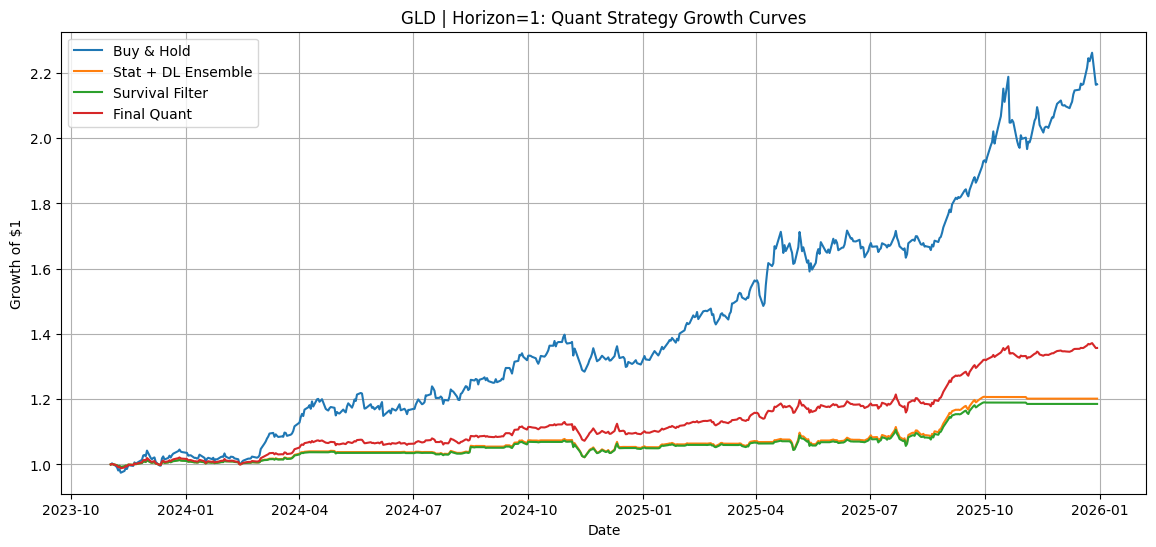

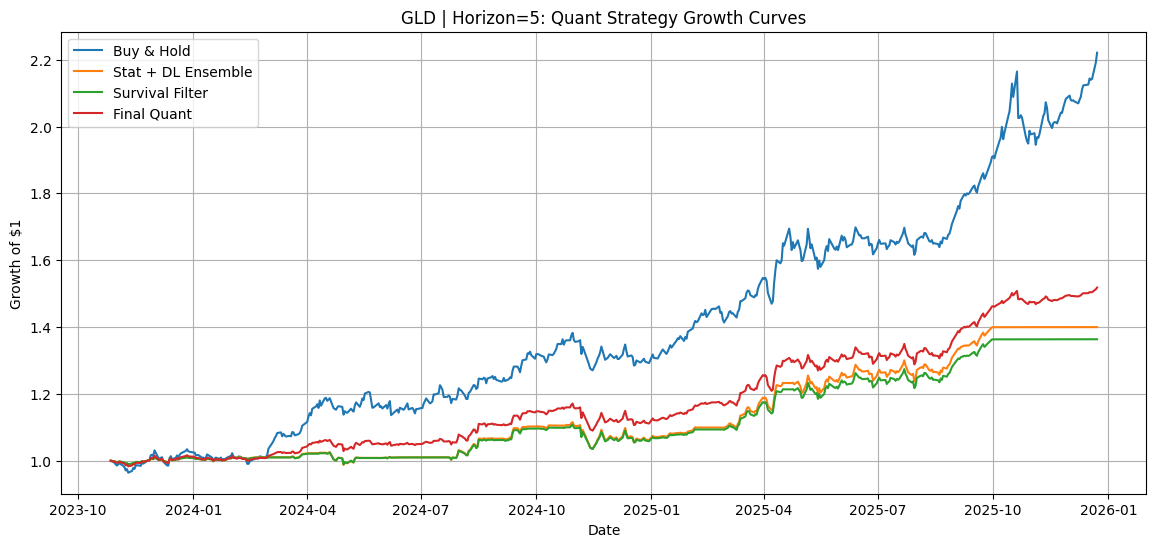

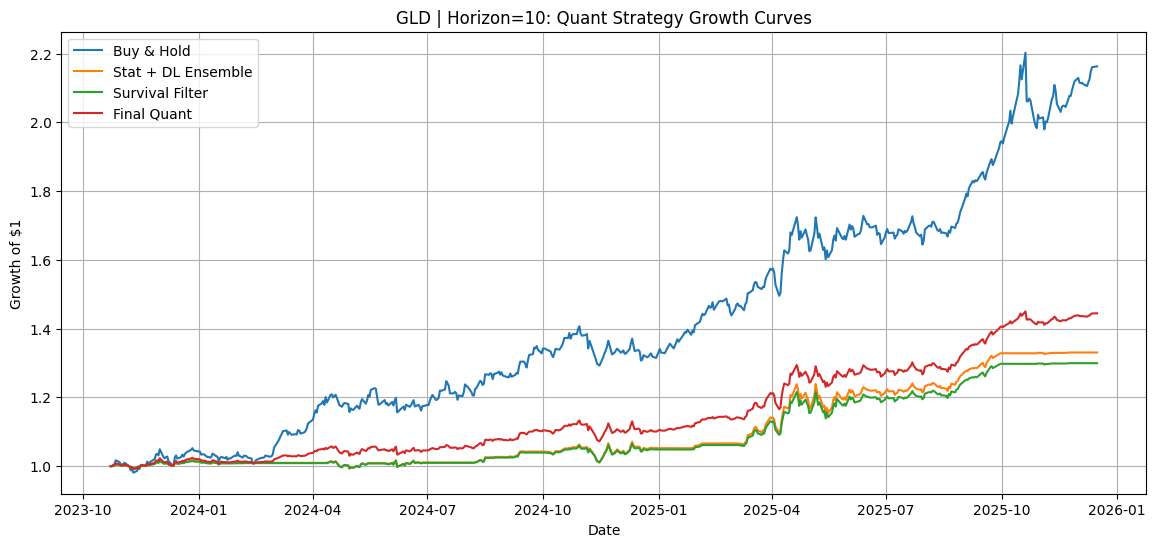

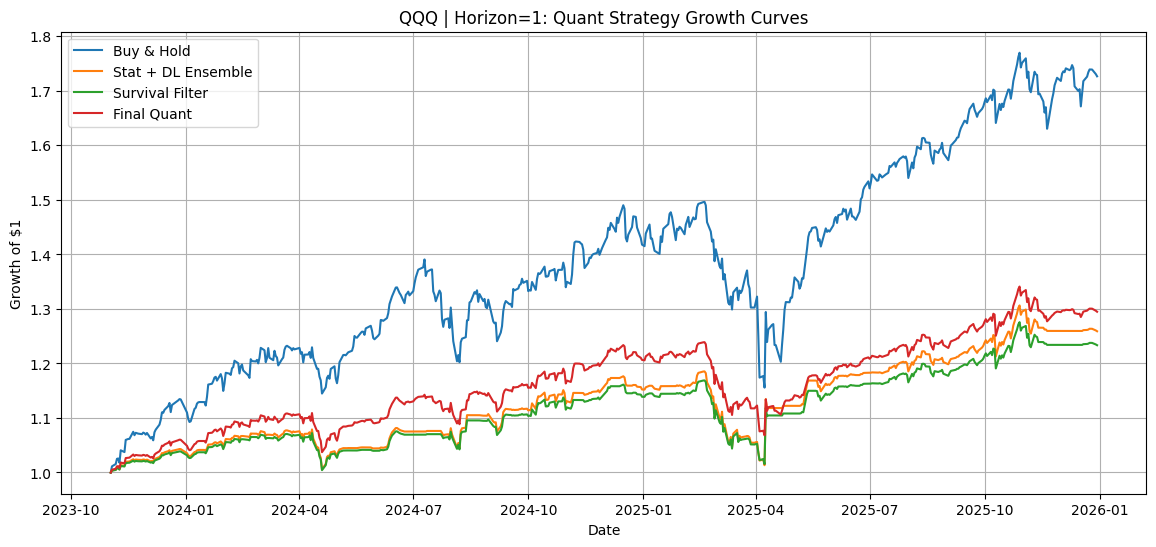

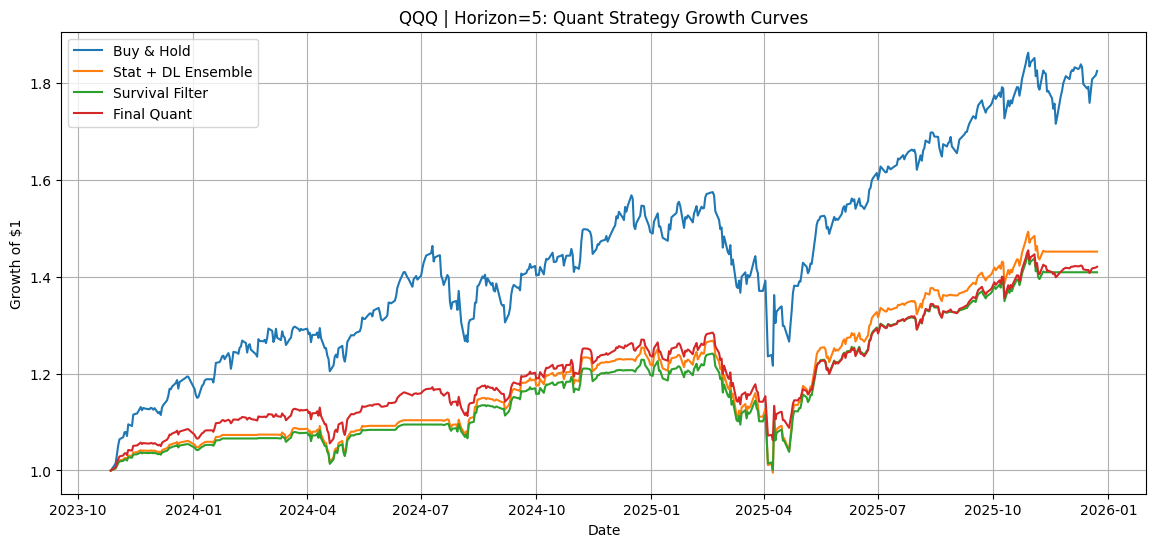

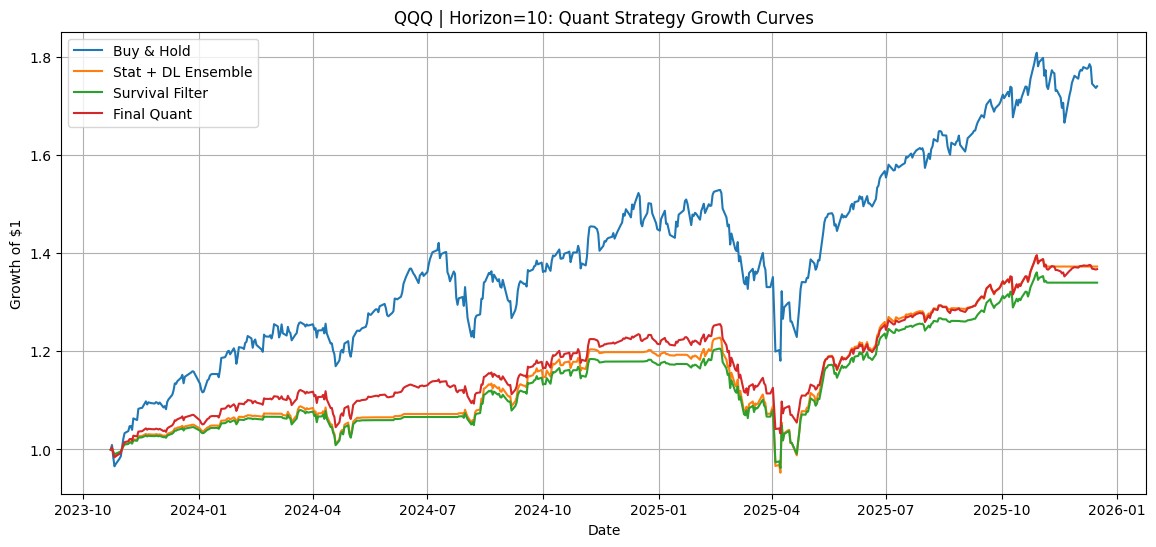

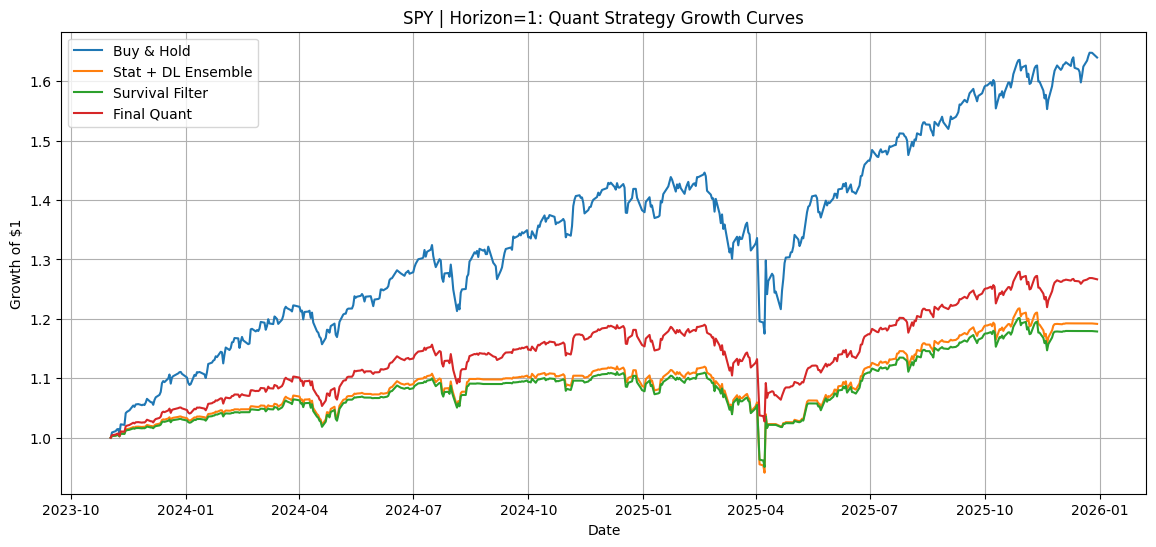

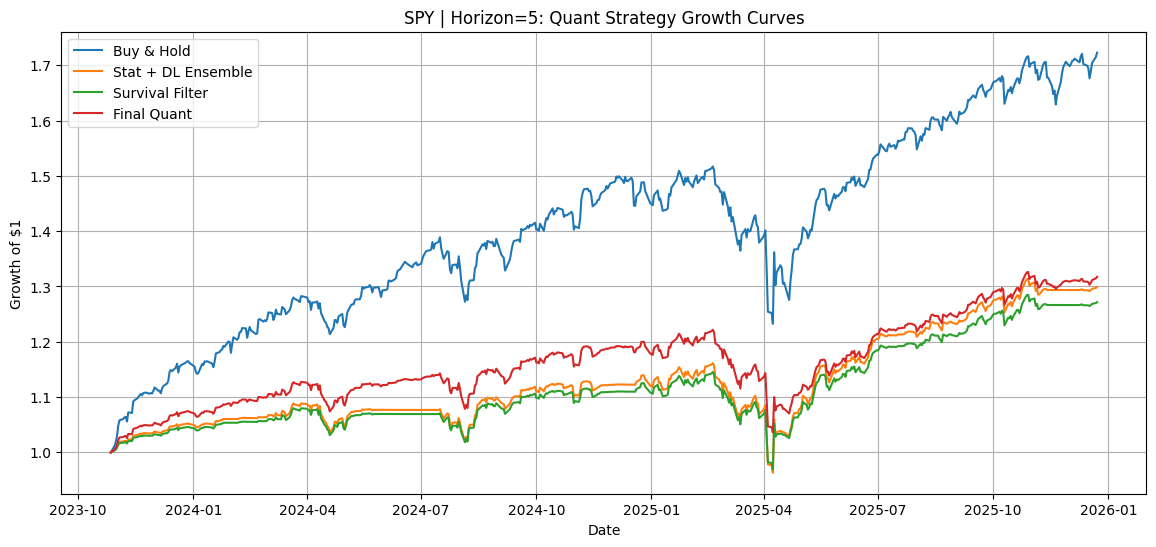

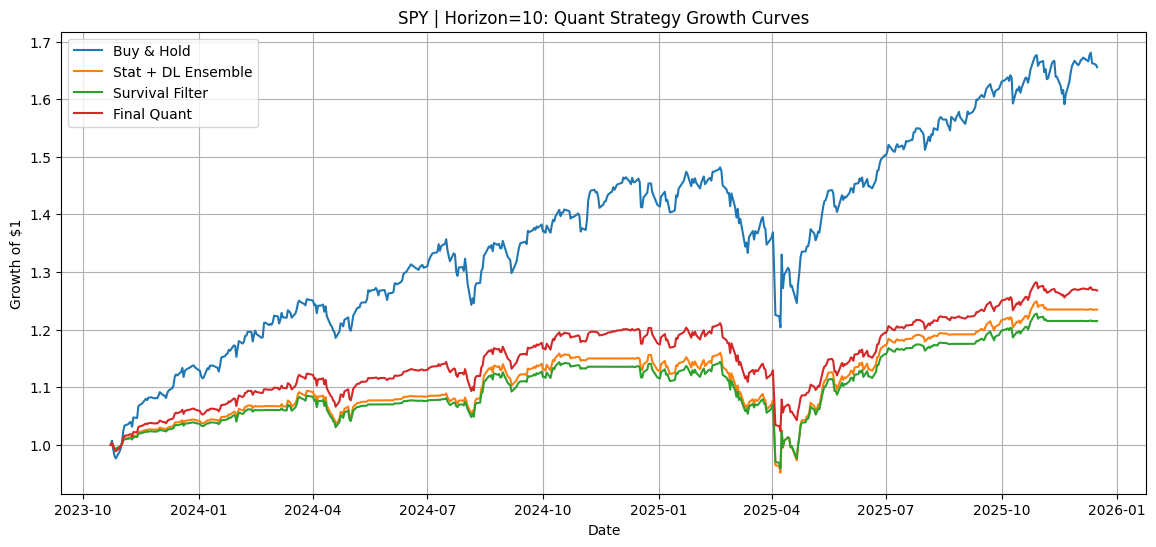

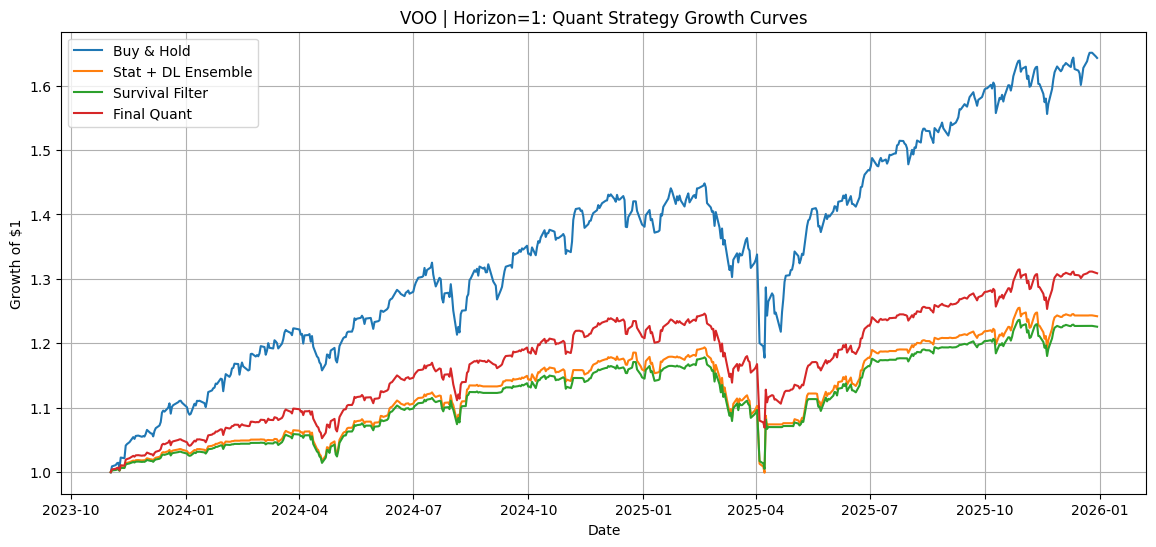

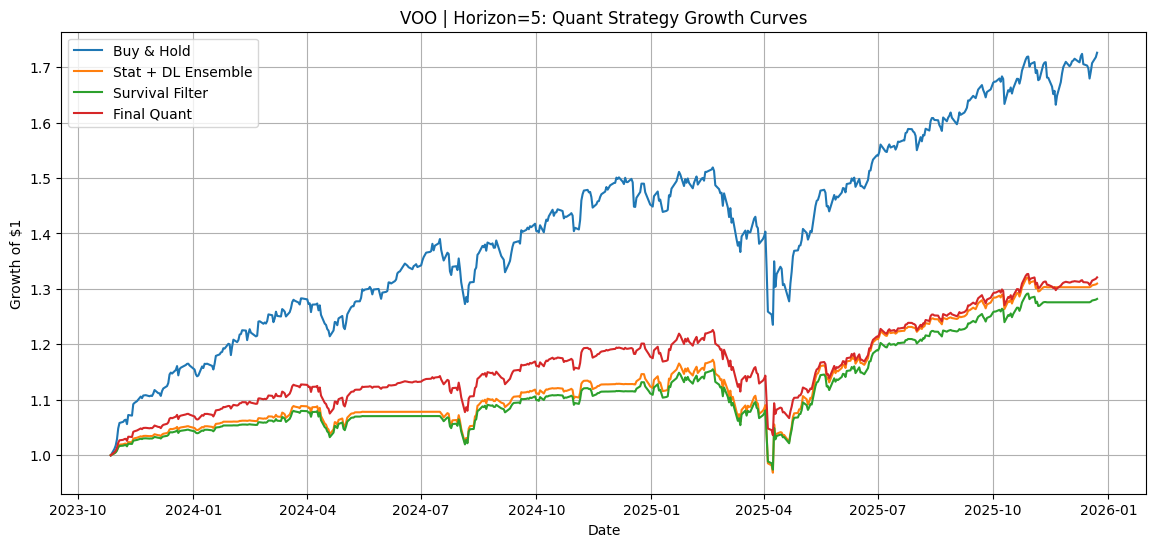

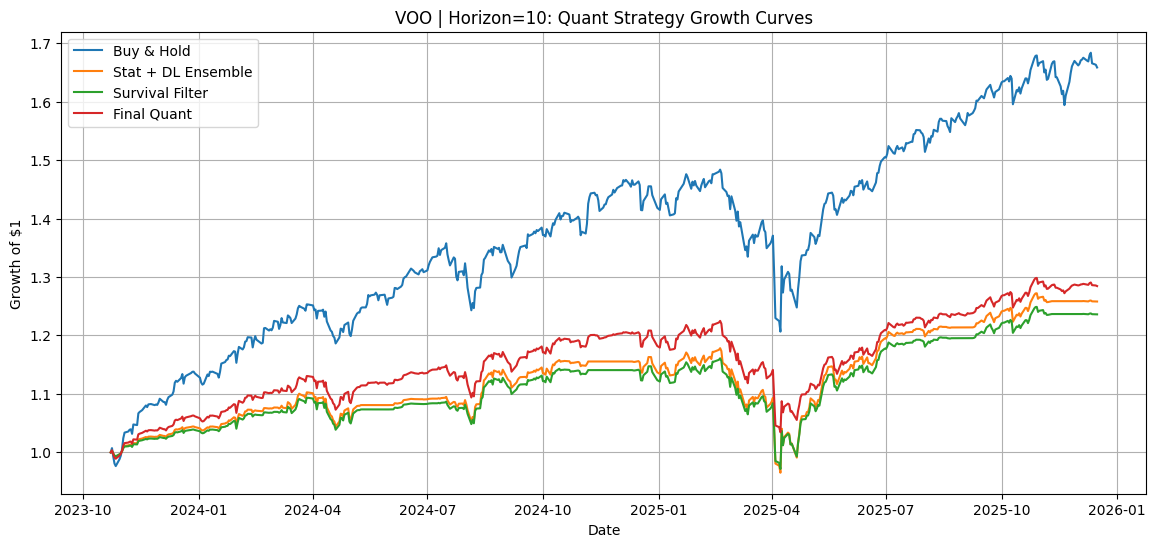

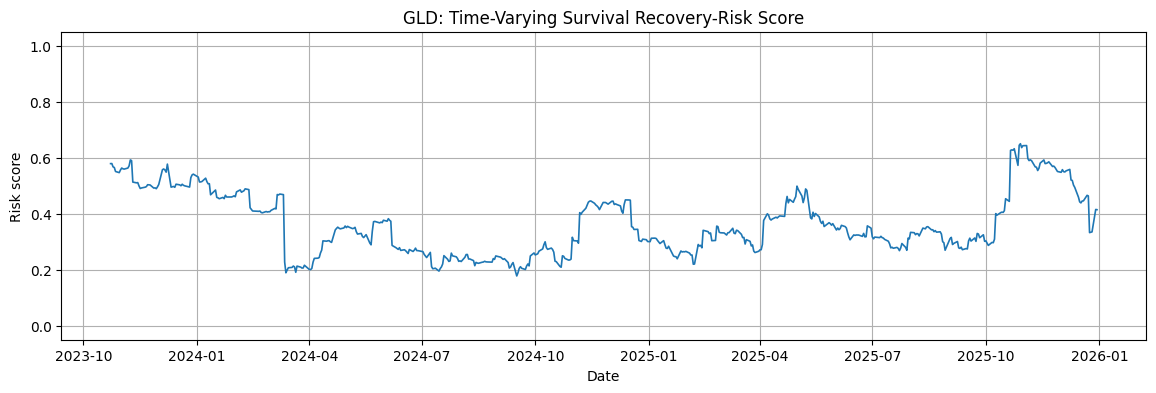

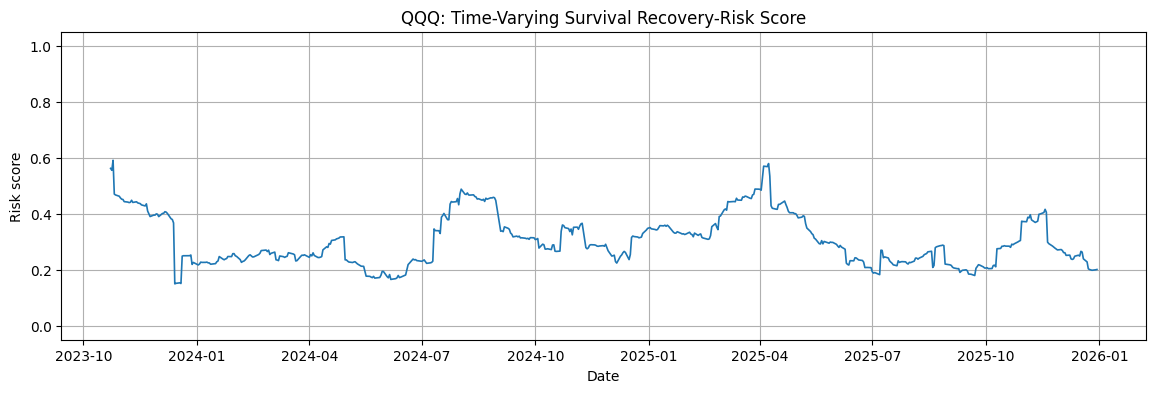

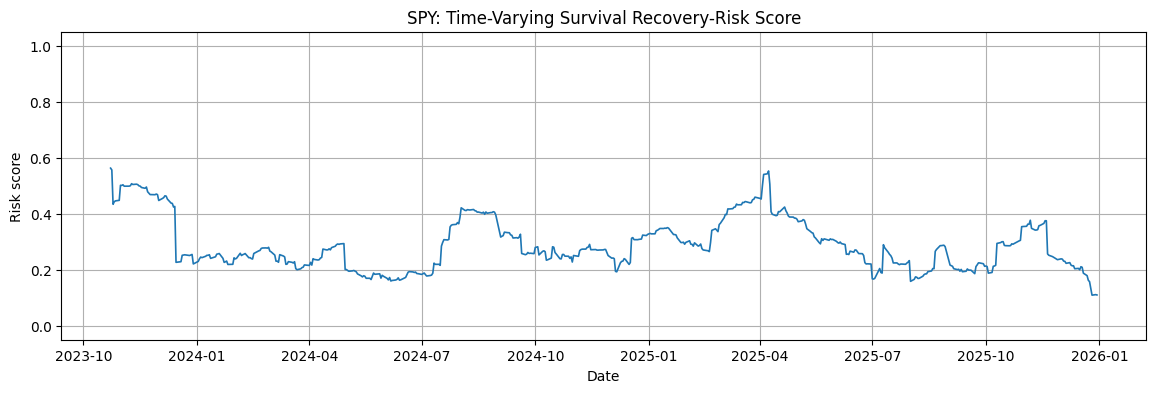

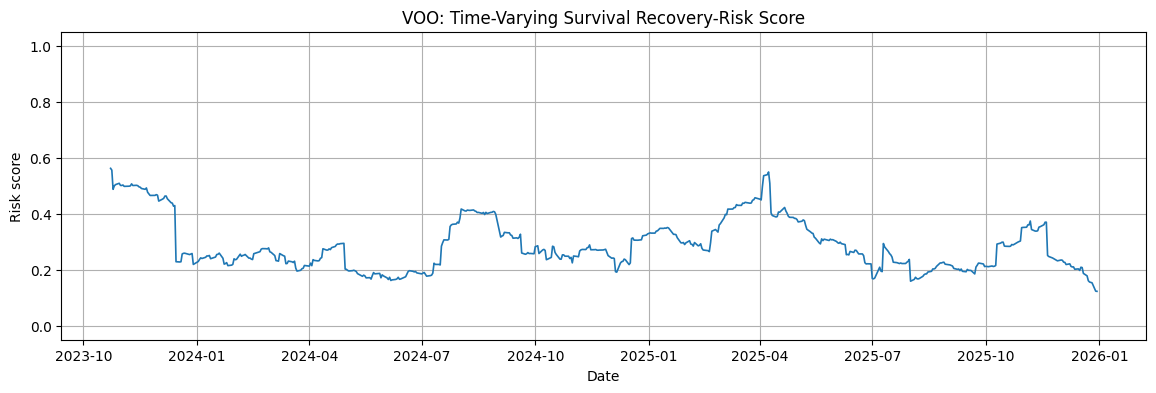

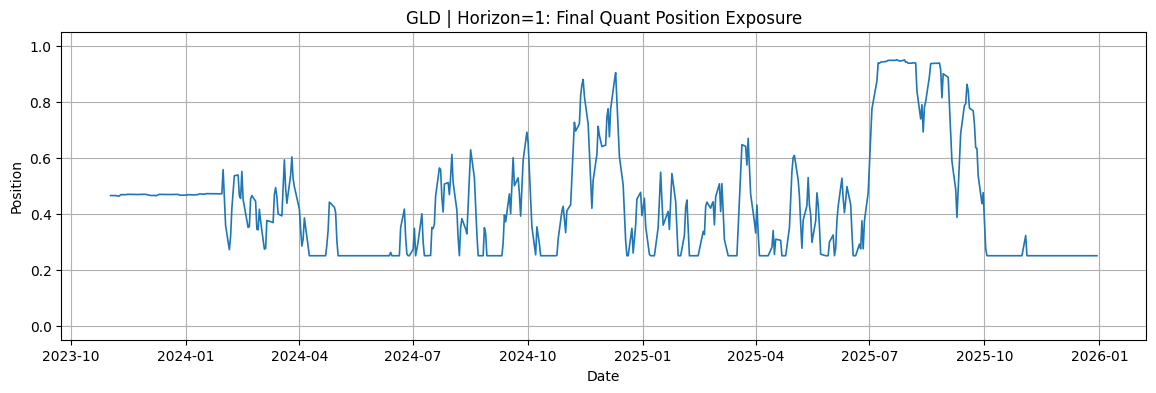

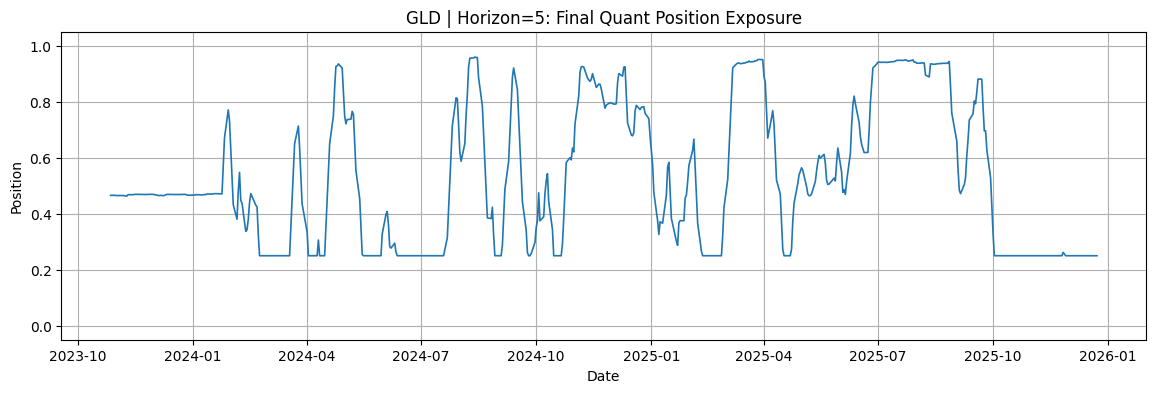

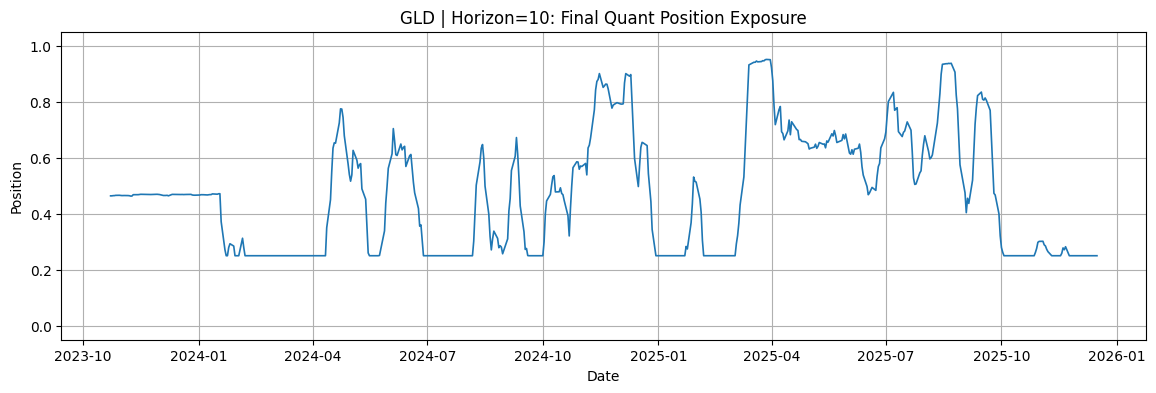

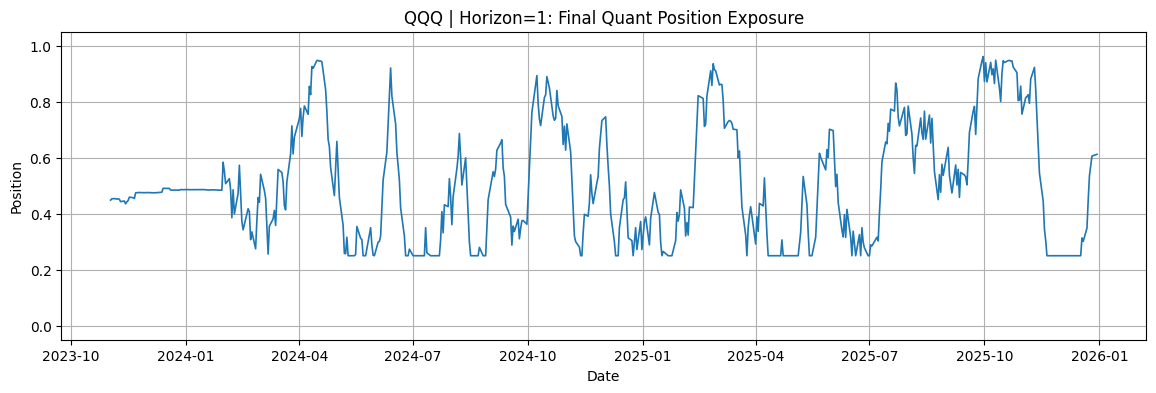

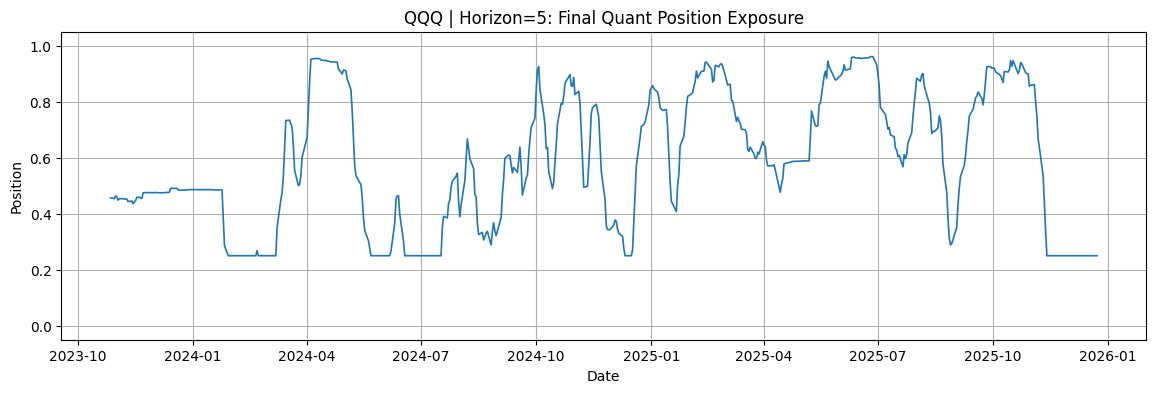

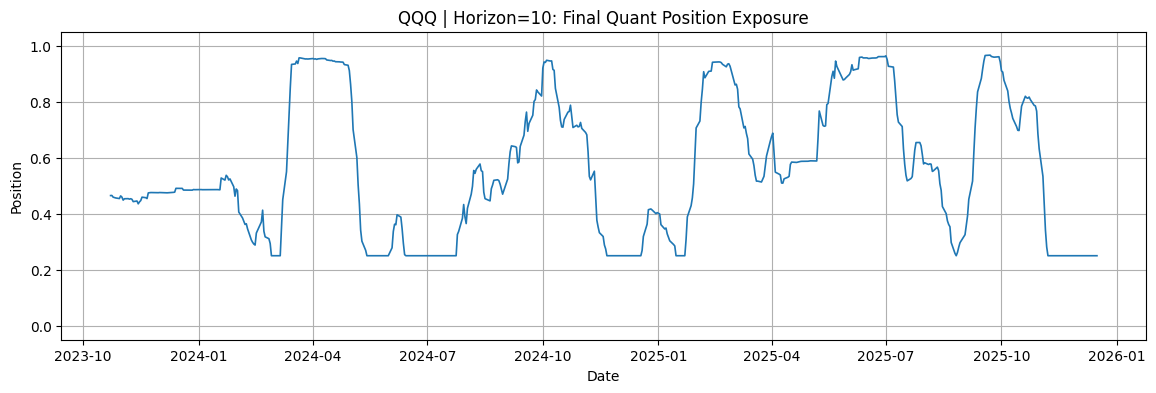

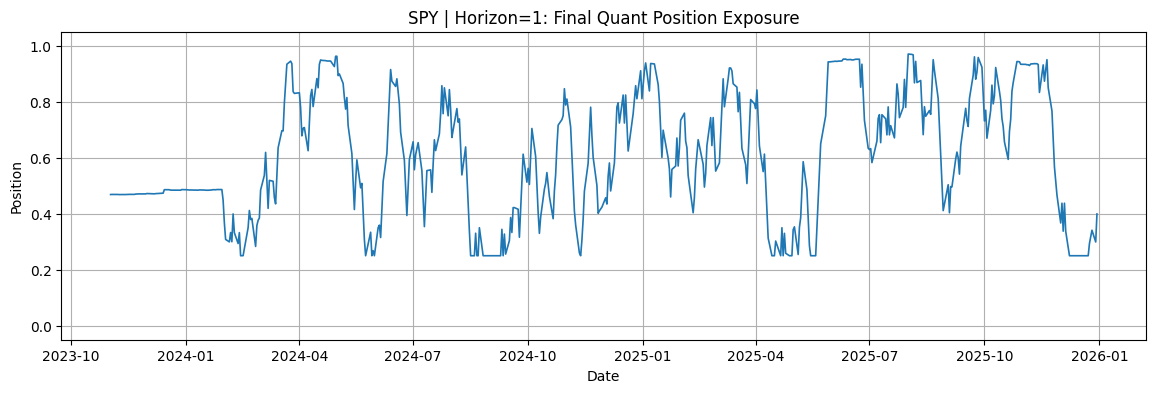

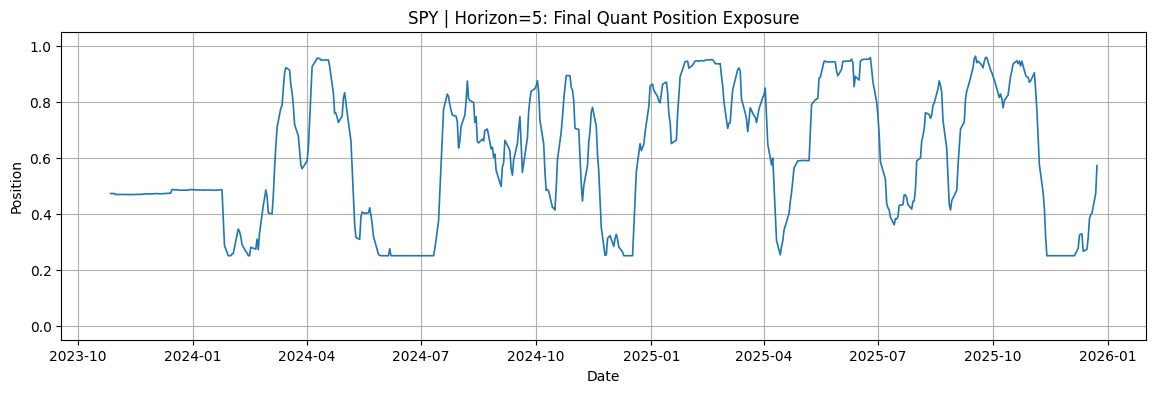

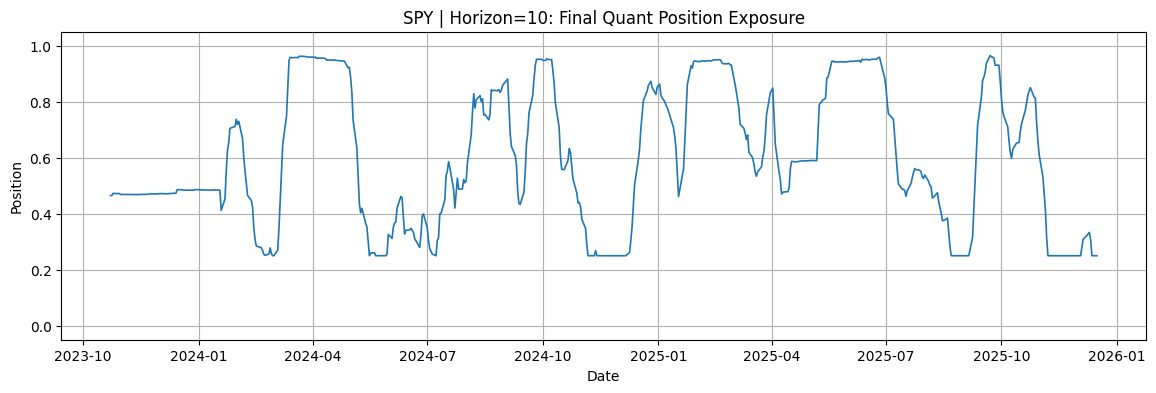

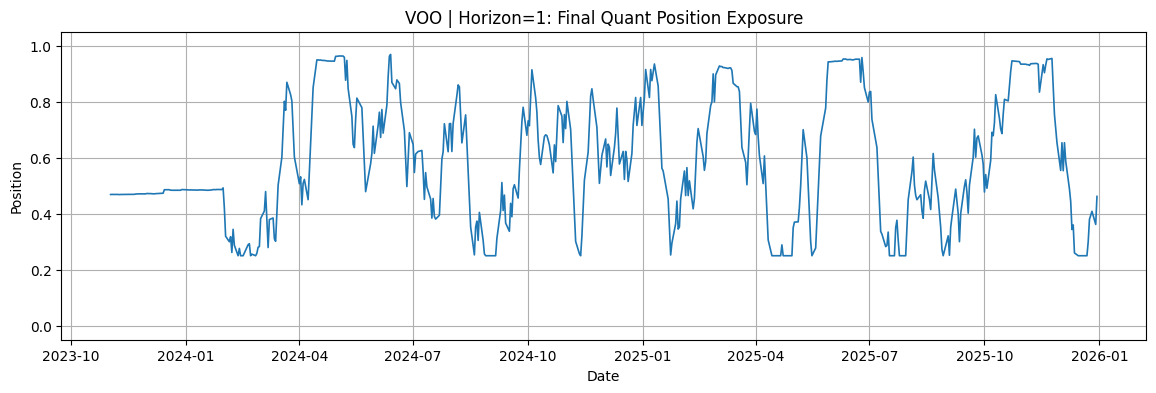

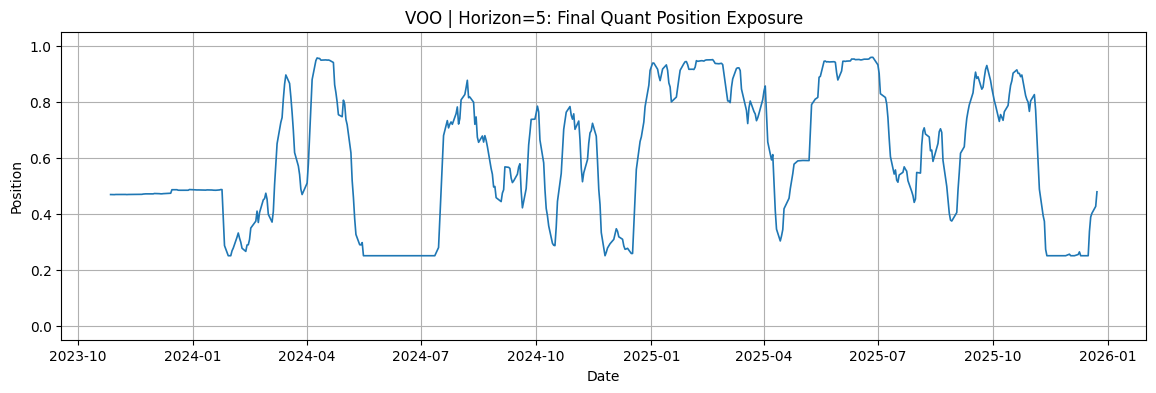

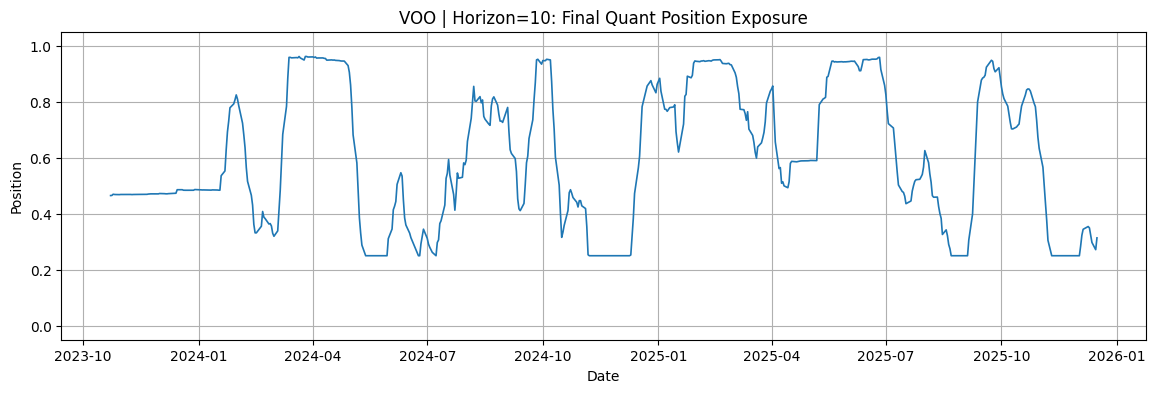

In [47]:
# ============================================================
# 10. Plot strategy curves and exposure
# ============================================================

PLOT_STRATEGIES = {
    "Buy & Hold": "ret_buy_hold_net",
    "Stat + DL Ensemble": "ret_ensemble_net",
    "Survival Filter": "ret_ensemble_survival_filter_net",
    "Final Quant": "ret_quant_final_net",
}

# Growth curves.
for (etf, horizon), g in strategy_df.groupby(["ETF", "horizon"]):
    g = g.sort_values("date").copy()
    plt.figure(figsize=(14, 6))
    for label, ret_col in PLOT_STRATEGIES.items():
        if ret_col not in g.columns:
            continue
        growth = np.exp(g[ret_col].fillna(0).cumsum())
        plt.plot(g["date"], growth, label=label, linewidth=1.5)
    plt.title(f"{etf} | Horizon={horizon}: Quant Strategy Growth Curves")
    plt.xlabel("Date")
    plt.ylabel("Growth of $1")
    plt.grid(True)
    plt.legend()
    plt.show()

# Daily survival risk diagnostic.
for etf, g in strategy_df.groupby("ETF"):
    g = g.sort_values("date").drop_duplicates("date").copy()
    plt.figure(figsize=(14, 4))
    plt.plot(g["date"], g["survival_risk_score"], linewidth=1.2)
    plt.title(f"{etf}: Time-Varying Survival Recovery-Risk Score")
    plt.xlabel("Date")
    plt.ylabel("Risk score")
    plt.ylim(-0.05, 1.05)
    plt.grid(True)
    plt.show()

# Final Quant exposure plot.
for (etf, horizon), g in strategy_df.groupby(["ETF", "horizon"]):
    g = g.sort_values("date").copy()
    if "pos_quant_final" not in g.columns:
        continue
    plt.figure(figsize=(14, 4))
    plt.plot(g["date"], g["pos_quant_final"], linewidth=1.2)
    plt.title(f"{etf} | Horizon={horizon}: Final Quant Position Exposure")
    plt.xlabel("Date")
    plt.ylabel("Position")
    plt.ylim(-0.05, 1.05)
    plt.grid(True)
    plt.show()


## 11. Interpretation helper

Use this table in your report. The most important columns are:

- `sharpe`: higher is better;
- `sortino`: higher is better;
- `max_drawdown`: closer to 0 is better;
- `VaR_95` and `ES_95`: lower is better;
- `longest_recovery_days`: lower is better;
- `final_growth_multiple`: higher is better.

The strongest conclusion would be:

> The final quant strategy may not always maximize raw return, but it should ideally improve risk-adjusted performance and reduce drawdown/recovery risk compared with the prediction-only strategy.

In [48]:
# ============================================================
# 11. Compact report table
# ============================================================

report_cols = [
    "ETF", "horizon", "strategy", "ann_return", "ann_vol", "sharpe", "sortino",
    "max_drawdown", "VaR_95", "ES_95", "final_growth_multiple",
    "longest_recovery_days", "annual_turnover"
]

compact_report = performance_df[report_cols].copy()

compact_report_path = os.path.join(WORKING_DIR, "quant_compact_report_table.csv")
compact_report.to_csv(compact_report_path, index=False)

print("Saved:", compact_report_path)
display(compact_report.sort_values(["ETF", "horizon", "strategy"]))


Saved: /kaggle/working/quant_compact_report_table.csv


,ETF,horizon,strategy,ann_return,ann_vol,sharpe,sortino,max_drawdown,VaR_95,ES_95,final_growth_multiple,longest_recovery_days,annual_turnover
0,GLD,1,Buy & Hold,0.433156,0.173730,2.493272,3.328371,-0.101277,0.017094,0.024639,2.165385,91.0,0.465804
2,GLD,1,Deep Learning Only,0.075325,0.070386,1.070172,1.247737,-0.051535,0.005659,0.010342,1.168721,172.0,18.823236
5,GLD,1,Final Quant: Ensemble + Survival + Vol Target,0.152804,0.074552,2.049643,2.887717,-0.051043,0.006839,0.010399,1.356995,102.0,10.301662
4,GLD,1,Stat + DL + Survival Filter,0.082449,0.060046,1.373098,1.583019,-0.047460,0.005044,0.008780,1.185404,187.0,17.695418
3,GLD,1,Stat + DL Ensemble,0.089305,0.066008,1.352933,1.556698,-0.052143,0.005416,0.009670,1.201582,172.0,19.214180
...,...,...,...,...,...,...,...,...,...,...,...,...,...
68,VOO,10,Deep Learning Only,0.108887,0.112130,0.971076,1.029714,-0.151687,0.010705,0.018853,1.247920,124.0,7.519221
71,VOO,10,Final Quant: Ensemble + Survival + Vol Target,0.123879,0.104513,1.185296,1.329774,-0.155615,0.009698,0.016650,1.284355,153.0,6.171191
70,VOO,10,Stat + DL + Survival Filter,0.103907,0.108090,0.961294,1.026661,-0.163188,0.009128,0.016829,1.235942,139.0,7.828498
69,VOO,10,Stat + DL Ensemble,0.113026,0.120317,0.939408,0.998722,-0.180944,0.009775,0.018581,1.257925,139.0,8.308507


In [49]:
# ============================================================
# Diagnose exposure after strategy construction
# ============================================================

position_cols = [c for c in strategy_df.columns if c.startswith("pos_")]

print("Position columns:")
print(position_cols)

exposure_tables = []
for c in position_cols:
    tmp = (
        strategy_df.groupby(["ETF", "horizon"])[c]
        .agg(["min", "mean", "max", "std"])
        .reset_index()
    )
    tmp["position_column"] = c
    exposure_tables.append(tmp)

exposure_diagnostics = pd.concat(exposure_tables, ignore_index=True)
exposure_path = os.path.join(WORKING_DIR, "quant_position_exposure_diagnostics.csv")
exposure_diagnostics.to_csv(exposure_path, index=False)

print("Saved:", exposure_path)
display(exposure_diagnostics)


Position columns:
['pos_buy_hold', 'pos_stat_only', 'pos_dl_only', 'pos_ensemble', 'pos_ensemble_survival_filter', 'pos_quant_final']
Saved: /kaggle/working/quant_position_exposure_diagnostics.csv


,ETF,horizon,min,mean,max,std,position_column
0,GLD,1,1.00,1.000000,1.000000,0.000000,pos_buy_hold
1,GLD,5,1.00,1.000000,1.000000,0.000000,pos_buy_hold
2,GLD,10,1.00,1.000000,1.000000,0.000000,pos_buy_hold
3,QQQ,1,1.00,1.000000,1.000000,0.000000,pos_buy_hold
4,QQQ,5,1.00,1.000000,1.000000,0.000000,pos_buy_hold
...,...,...,...,...,...,...,...
67,SPY,5,0.25,0.612516,0.962718,0.235376,pos_quant_final
68,SPY,10,0.25,0.601182,0.965129,0.242746,pos_quant_final
69,VOO,1,0.25,0.588508,0.968893,0.219000,pos_quant_final
70,VOO,5,0.25,0.600670,0.958610,0.235082,pos_quant_final
